# ms3.2.0 — LoRA Augmented Baseline

**Goal**: Test whether adding LoRA-generated synthetic images for the worst-10 artists improves baseline classification accuracy.

**Setup**:
- **Model**: ResNet-18, frozen backbone + linear head (simplest baseline)
- **Run A (baseline)**: load teammate's pre-trained weights (`output/resnet18_frozen_artist.pt`), inference only
- **Run B (augmented)**: same architecture, retrained on `real_train + 200×10 LoRA synth`
- Test set is **identical** in both runs (real images only, `random_state=42` split)

**Key invariant**: synthetic images go into TRAIN ONLY. Val/test stay 100% real.

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, re, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths
PROJECT_DIR  = '/content/drive/MyDrive/Colab Notebooks/209b_project'
BASE_DIR     = os.path.join(PROJECT_DIR, 'data')
CSV_PATH     = os.path.join(BASE_DIR, 'artists.csv')
IMG_DIR      = os.path.join(BASE_DIR, 'resized')
LORA_DIR     = os.path.join(PROJECT_DIR, 'lora_worst10_all', 'generated_lora')
BASELINE_OUT = os.path.join(PROJECT_DIR, 'output')          # teammate's, read-only
OUT_DIR      = os.path.join(PROJECT_DIR, 'output_lora_exp') # ours, writes go here
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

print(f'Device:        {device}')
print(f'Real images:   {len(os.listdir(IMG_DIR))} files in {IMG_DIR}')
print(f'LoRA dir:      {LORA_DIR}')
print(f'Output dir:    {OUT_DIR}')

Device:        cuda
Real images:   8355 files in /content/drive/MyDrive/Colab Notebooks/209b_project/data/resized
LoRA dir:      /content/drive/MyDrive/Colab Notebooks/209b_project/lora_worst10_all/generated_lora
Output dir:    /content/drive/MyDrive/Colab Notebooks/209b_project/output_lora_exp


## 2. Real data — same split as baseline (`random_state=42`)

In [ ]:
df = pd.read_csv(CSV_PATH)
df['name_key'] = df['name'].str.replace(' ', '_')
name_key_to_name = dict(zip(df['name_key'], df['name']))

img_files = sorted(os.listdir(IMG_DIR))
all_paths_real, all_labels_real = [], []
for fname in img_files:
    if not fname.endswith('.jpg'):
        continue
    name_key = '_'.join(fname.split('_')[:-1])
    name = name_key_to_name.get(name_key)
    if name is None:
        continue
    all_paths_real.append(os.path.join(IMG_DIR, fname))
    all_labels_real.append(name)

le = LabelEncoder()
all_labels_enc = le.fit_transform(all_labels_real)
n_classes = len(le.classes_)
print(f'Total real images: {len(all_paths_real)},  Classes: {n_classes}')

# IMPORTANT: must match baseline split exactly (same random_state, same test_size sequence)
X_tv, X_test, y_tv, y_test = train_test_split(
    all_paths_real, all_labels_enc, test_size=0.10, stratify=all_labels_enc, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.111, stratify=y_tv, random_state=SEED)
print(f'Train: {len(X_train)},  Val: {len(X_val)},  Test: {len(X_test)}')

Total real images: 8027,  Classes: 49
Train: 6422,  Val: 802,  Test: 803


In [ ]:
# Transforms (same as baseline)
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class ArtDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img), self.labels[idx]

## 3. Synthetic data — LoRA-generated, only for worst-10 artists

Each painter's folder under `generated_lora/<name_lower>/` has ~200 PNG images named `gen_*.png`. We append them **only to the training set** — val and test are untouched.

In [ ]:
# Map lowercase folder name -> proper CSV name_key (then to display name -> encoded label)
lower_to_namekey = {nk.lower(): nk for nk in df['name_key']}

X_synth, y_synth = [], []
synth_per_artist = {}
for folder in sorted(os.listdir(LORA_DIR)):
    full = os.path.join(LORA_DIR, folder)
    if not os.path.isdir(full):
        continue
    name_key = lower_to_namekey.get(folder.lower())
    if name_key is None:
        print(f'  ⚠ skip {folder} — not in CSV')
        continue
    display_name = name_key_to_name[name_key]
    if display_name not in le.classes_:
        print(f'  ⚠ skip {folder} — {display_name} not in label encoder')
        continue
    label = le.transform([display_name])[0]
    imgs = [f for f in os.listdir(full) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    for f in imgs:
        X_synth.append(os.path.join(full, f))
        y_synth.append(label)
    synth_per_artist[display_name] = len(imgs)

y_synth = np.array(y_synth)
print(f'Loaded {len(X_synth)} synthetic images across {len(synth_per_artist)} artists\n')
for name, n in synth_per_artist.items():
    print(f'  {name:<25} {n}')

WORST10 = sorted(synth_per_artist.keys())
WORST10_LABELS = le.transform(WORST10)

Loaded 2000 synthetic images across 10 artists

  Andrei Rublev             200
  Claude Monet              200
  Eugene Delacroix          200
  Gustave Courbet           200
  Kazimir Malevich          200
  Mikhail Vrubel            200
  Paul Cezanne              200
  Titian                    200
  Vasiliy Kandinskiy        200
  Vincent van Gogh          200


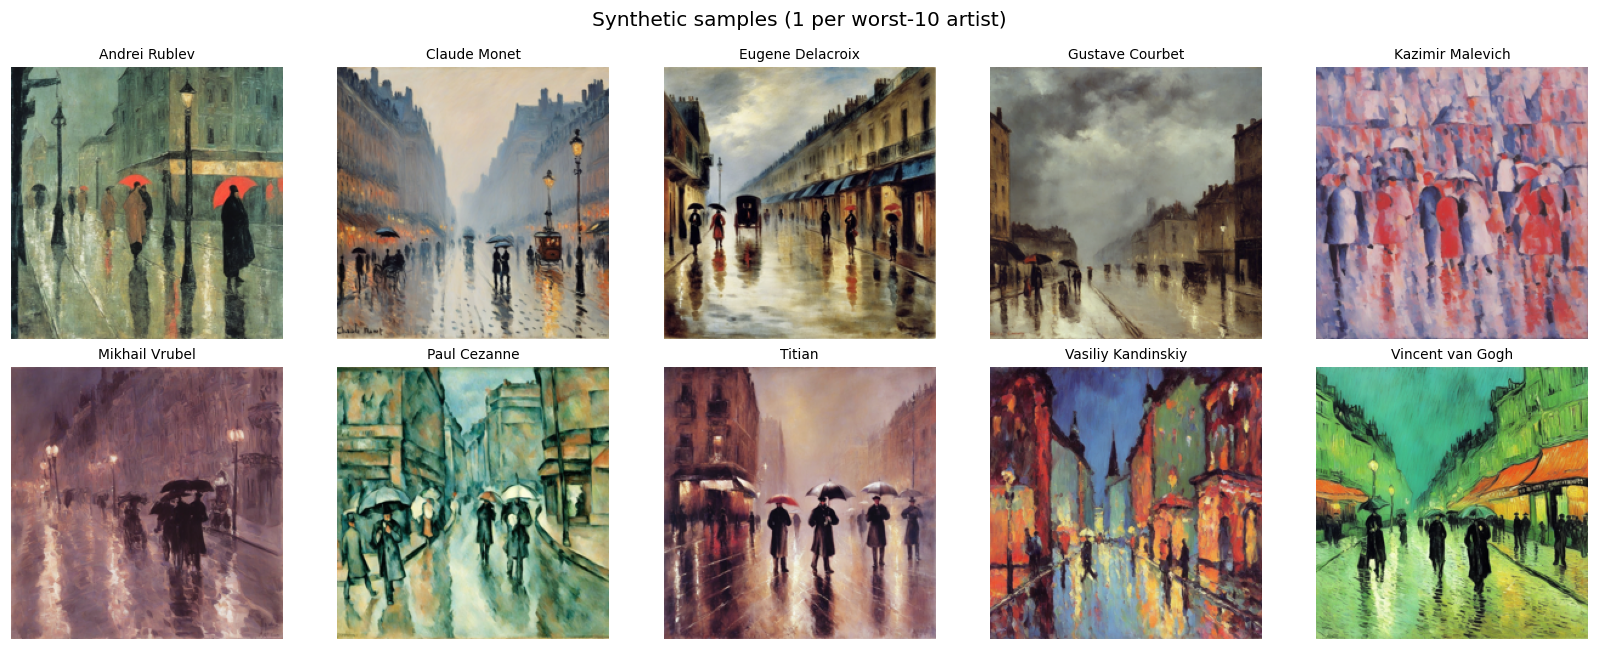

In [ ]:
# Quick visual sanity check: show a few synthetic images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, name in zip(axes.flatten(), WORST10):
    label = le.transform([name])[0]
    idxs = np.where(y_synth == label)[0]
    if len(idxs) == 0: continue
    img = Image.open(X_synth[idxs[0]]).convert('RGB').resize((224, 224))
    ax.imshow(img); ax.set_title(name, fontsize=9); ax.axis('off')
plt.suptitle('Synthetic samples (1 per worst-10 artist)')
plt.tight_layout(); plt.show()

In [ ]:
# Build augmented training set: REAL train + ALL synthetic.  Val/test untouched.
X_train_aug = list(X_train) + list(X_synth)
y_train_aug = np.concatenate([y_train, y_synth])
is_synth_flag = np.array([0]*len(X_train) + [1]*len(X_synth))   # for analysis later

print(f'Original train: {len(X_train):>5}')
print(f'Synthetic add:  {len(X_synth):>5}')
print(f'Augmented train:{len(X_train_aug):>5}')
print(f'Val (unchanged):{len(X_val):>5}')
print(f'Test (unchanged):{len(X_test):>4}')

Original train:  6422
Synthetic add:   2000
Augmented train: 8422
Val (unchanged):  802
Test (unchanged): 803


## 3b. (Optional) I/O speedup — cache images to local SSD

Drive reads are slow per-file. Caching to `/content/` and using `num_workers>0` typically gives 5-10x speedup. Re-run this cell, then the loaders defined here override the slower ones in §4 / §5.

In [ ]:
# ───────────────────────────────────────────────────────────────────
# I/O optimization: cache Drive images to local SSD (/content/cache_imgs)
# Run this AFTER cells 1-10 (data setup) and BEFORE re-running Experiment A/B.
# One-time copy ~10k files. After this, every epoch reads from local disk,
# typically 5-10x faster than reading from Drive each time.
# Re-creates: X_train, X_val, X_test, X_synth, X_train_aug to point at local paths,
# and rebuilds test_loader / train_loader_aug / val_loader with num_workers=4.
# ───────────────────────────────────────────────────────────────────
import shutil
from pathlib import Path

LOCAL_CACHE = Path('/content/cache_imgs')
LOCAL_CACHE.mkdir(exist_ok=True)

def _local_path(src_path: str) -> str:
    """Map a Drive path to a unique local path under LOCAL_CACHE, copying if needed."""
    src = Path(src_path)
    # Use parent-dir + filename as the unique key (handles same filename in diff folders)
    key = f'{src.parent.name}__{src.name}'
    dst = LOCAL_CACHE / key
    if not dst.exists():
        shutil.copy(src, dst)
    return str(dst)

def _remap(paths):
    return [_local_path(p) for p in tqdm(paths, desc='copy', leave=False)]

# Copy + remap each path list in-place
print('Caching real train images...');  X_train = _remap(X_train)
print('Caching real val images...');    X_val   = _remap(X_val)
print('Caching real test images...');   X_test  = _remap(X_test)
print('Caching synthetic images...');   X_synth = _remap(X_synth)

# Rebuild augmented train list with local paths
X_train_aug = list(X_train) + list(X_synth)
# y_train_aug is unchanged (same labels, same order)

print(f'\nCache dir: {LOCAL_CACHE}  ({sum(1 for _ in LOCAL_CACHE.iterdir())} files)')
print(f'X_train: {len(X_train)}  X_val: {len(X_val)}  X_test: {len(X_test)}  X_synth: {len(X_synth)}  X_train_aug: {len(X_train_aug)}')

# Rebuild loaders with parallel workers + pinned memory
test_ds      = ArtDataset(X_test,      y_test,      val_tf)
train_ds_aug = ArtDataset(X_train_aug, y_train_aug, train_tf)
val_ds       = ArtDataset(X_val,       y_val,       val_tf)

label_counts = np.bincount(y_train_aug, minlength=n_classes)
weights = 1.0 / label_counts[y_train_aug]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

LOADER_KW = dict(num_workers=4, pin_memory=True, persistent_workers=True)
test_loader      = DataLoader(test_ds,      batch_size=64, shuffle=False,   **LOADER_KW)
val_loader       = DataLoader(val_ds,       batch_size=64, shuffle=False,   **LOADER_KW)
train_loader_aug = DataLoader(train_ds_aug, batch_size=32, sampler=sampler, **LOADER_KW)

print('Loaders rebuilt with num_workers=4, pin_memory=True.')
print('You can now re-run the inference / training cells below.')

Caching real train images...


Caching real val images...


Caching real test images...


Caching synthetic images...



Cache dir: /content/cache_imgs  (10027 files)
X_train: 6422  X_val: 802  X_test: 803  X_synth: 2000  X_train_aug: 8422
Loaders rebuilt with num_workers=4, pin_memory=True.
You can now re-run the inference / training cells below.


## 4. Experiment A — Baseline (load teammate's frozen ResNet-18)

No retraining. Just rebuild the architecture, load weights, evaluate on the real test set.

In [ ]:
def build_resnet18_frozen(n_classes):
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for p in m.parameters():
        p.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, n_classes)
    return m

model_A = build_resnet18_frozen(n_classes).to(device)
ckpt_A = os.path.join(BASELINE_OUT, 'resnet18_frozen_artist.pt')
model_A.load_state_dict(torch.load(ckpt_A, map_location=device))
model_A.eval()
print(f'Loaded baseline weights from {ckpt_A}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


Loaded baseline weights from /content/drive/MyDrive/Colab Notebooks/209b_project/output/resnet18_frozen_artist.pt


In [ ]:
# Inference on real test set
test_ds = ArtDataset(X_test, y_test, val_tf)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)

def run_inference(model, loader):
    model.eval()
    preds_all, true_all, probs_all = [], [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='Inference', leave=False):
            logits = model(imgs.to(device))
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds_all.extend(probs.argmax(1))
            true_all.extend(labels.numpy())
            probs_all.append(probs)
    return (np.array(preds_all), np.array(true_all), np.concatenate(probs_all))

preds_A, true_test, probs_A = run_inference(model_A, test_loader)
acc_A = (preds_A == true_test).mean()
print(f'\n[A: Baseline] Test accuracy = {acc_A:.4f}')
np.savez(os.path.join(OUT_DIR, 'preds_A_baseline.npz'),
         preds=preds_A, true=true_test, probs=probs_A)


[A: Baseline] Test accuracy = 0.5205


## 5. Experiment B — Augmented (retrain on real + LoRA synth)

Same architecture, same hyperparameters as baseline (Adam, lr=1e-3, StepLR γ=0.5/3, 10 epochs).

In [ ]:
# Loaders for augmented training
train_ds_aug = ArtDataset(X_train_aug, y_train_aug, train_tf)
val_ds       = ArtDataset(X_val,        y_val,        val_tf)

# WeightedRandomSampler with updated counts (worst-10 now have ~200 more each)
label_counts = np.bincount(y_train_aug, minlength=n_classes)
weights = 1.0 / label_counts[y_train_aug]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader_aug = DataLoader(train_ds_aug, batch_size=32, sampler=sampler, num_workers=2)
val_loader       = DataLoader(val_ds,        batch_size=64, shuffle=False, num_workers=2)

print('Per-class counts in augmented train (worst-10 highlighted):')
for cls_idx in range(n_classes):
    name = le.classes_[cls_idx]
    star = ' *' if name in WORST10 else ''
    print(f'  {name:<28} {label_counts[cls_idx]:>4}{star}')

Per-class counts in augmented train (worst-10 highlighted):
  Alfred Sisley                 207
  Amedeo Modigliani             155
  Andrei Rublev                 279 *
  Andy Warhol                   145
  Camille Pissarro               73
  Caravaggio                     44
  Claude Monet                  259 *
  Diego Rivera                   56
  Diego Velazquez                29
  Edgar Degas                   562
  Edouard Manet                  72
  Edvard Munch                   53
  El Greco                       69
  Eugene Delacroix              225 *
  Francisco Goya                233
  Frida Kahlo                    96
  Georges Seurat                 35
  Giotto di Bondone              95
  Gustav Klimt                   93
  Gustave Courbet               247 *
  Henri Matisse                 148
  Henri Rousseau                 56
  Henri de Toulouse-Lautrec      65
  Hieronymus Bosch              109
  Jackson Pollock                20
  Jan van Eyck                  

In [ ]:
# Build a fresh model and train
model_B = build_resnet18_frozen(n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_B.fc.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

N_EPOCHS = 10
TAG = 'resnet18_frozen_lora_aug'
HIST_PATH  = os.path.join(OUT_DIR, f'{TAG}_history.npy')
MODEL_PATH = os.path.join(OUT_DIR, f'{TAG}.pt')
CKPT_PATH  = os.path.join(OUT_DIR, f'{TAG}_checkpoint.pt')

def run_epoch(model, loader, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        pbar = tqdm(loader, desc=('train' if train else 'val'), leave=False)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            loss = criterion(out, labels)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * len(imgs)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += len(imgs)
            pbar.set_postfix(loss=f'{loss.item():.3f}')
    return total_loss / total, correct / total

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
start_epoch = 1

# Resume support
if os.path.exists(CKPT_PATH):
    ck = torch.load(CKPT_PATH, map_location=device)
    model_B.load_state_dict(ck['model'])
    optimizer.load_state_dict(ck['optimizer'])
    scheduler.load_state_dict(ck['scheduler'])
    history = ck['history']
    start_epoch = ck['epoch'] + 1
    print(f'Resumed from epoch {ck["epoch"]}')

if os.path.exists(MODEL_PATH) and os.path.exists(HIST_PATH):
    print('Found previously trained augmented model — loading instead of retraining.')
    model_B.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    history = np.load(HIST_PATH, allow_pickle=True).item()
else:
    for epoch in range(start_epoch, N_EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model_B, train_loader_aug, optimizer=optimizer, train=True)
        va_loss, va_acc = run_epoch(model_B, val_loader,        train=False)
        scheduler.step()
        history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc);   history['val_acc'].append(va_acc)
        print(f'Epoch {epoch:02d}/{N_EPOCHS} | train {tr_loss:.3f}/{tr_acc:.3f} | '
              f'val {va_loss:.3f}/{va_acc:.3f} | {time.time()-t0:.1f}s')
        torch.save({'epoch': epoch, 'model': model_B.state_dict(),
                    'optimizer': optimizer.state_dict(),
                    'scheduler': scheduler.state_dict(),
                    'history': history}, CKPT_PATH)
    np.save(HIST_PATH, history)
    torch.save(model_B.state_dict(), MODEL_PATH)
    if os.path.exists(CKPT_PATH): os.remove(CKPT_PATH)
    print(f'Saved → {MODEL_PATH}')

Epoch 01/10 | train 2.897/0.297 | val 2.538/0.344 | 387.2s


Epoch 02/10 | train 1.986/0.508 | val 2.187/0.411 | 248.7s


Epoch 03/10 | train 1.663/0.573 | val 2.020/0.474 | 181.5s


Epoch 04/10 | train 1.496/0.620 | val 1.987/0.473 | 130.8s


Epoch 05/10 | train 1.456/0.630 | val 1.922/0.481 | 110.9s


Epoch 06/10 | train 1.428/0.633 | val 1.902/0.494 | 90.6s


Epoch 07/10 | train 1.337/0.659 | val 1.865/0.490 | 83.3s


Epoch 08/10 | train 1.305/0.667 | val 1.856/0.484 | 80.3s


Epoch 09/10 | train 1.290/0.666 | val 1.794/0.510 | 80.6s


Epoch 10/10 | train 1.269/0.668 | val 1.829/0.498 | 76.6s
Saved → /content/drive/MyDrive/Colab Notebooks/209b_project/output_lora_exp/resnet18_frozen_lora_aug.pt


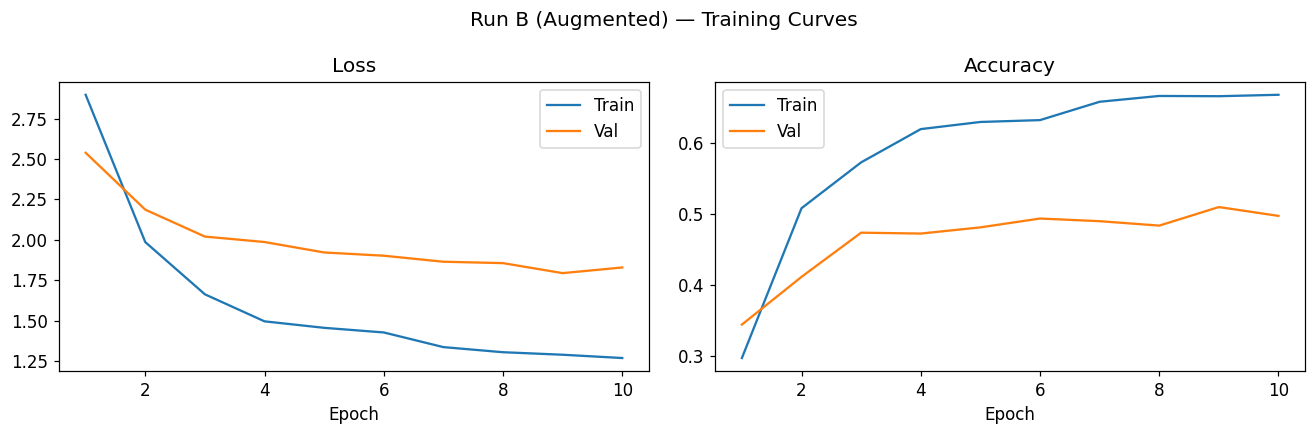


[B: Augmented] Test accuracy = 0.5243


In [ ]:
# Plot training curves
epochs_range = range(1, len(history['val_acc']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(epochs_range, history['train_acc'], label='Train')
axes[1].plot(epochs_range, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.suptitle('Run B (Augmented) — Training Curves')
plt.tight_layout(); plt.show()

# Inference on the same real test set
preds_B, _, probs_B = run_inference(model_B, test_loader)
acc_B = (preds_B == true_test).mean()
print(f'\n[B: Augmented] Test accuracy = {acc_B:.4f}')
np.savez(os.path.join(OUT_DIR, 'preds_B_augmented.npz'),
         preds=preds_B, true=true_test, probs=probs_B)

## 6. Comparison: did augmentation help?

In [ ]:
# Overall + worst-10 + others
rep_A = classification_report(true_test, preds_A, target_names=le.classes_, output_dict=True, zero_division=0)
rep_B = classification_report(true_test, preds_B, target_names=le.classes_, output_dict=True, zero_division=0)

rec_A = {c: rep_A[c]['recall'] for c in le.classes_}
rec_B = {c: rep_B[c]['recall'] for c in le.classes_}

print(f'{"":<30}{"A (base)":>12}{"B (aug)":>12}{"Δ":>10}')
print('-' * 64)
print(f'{"Overall test accuracy":<30}{acc_A:>12.4f}{acc_B:>12.4f}{acc_B-acc_A:>+10.4f}')

worst10_A = np.mean([rec_A[c] for c in WORST10])
worst10_B = np.mean([rec_B[c] for c in WORST10])
print(f'{"Mean recall — worst-10":<30}{worst10_A:>12.4f}{worst10_B:>12.4f}{worst10_B-worst10_A:>+10.4f}')

others = [c for c in le.classes_ if c not in WORST10]
other_A = np.mean([rec_A[c] for c in others])
other_B = np.mean([rec_B[c] for c in others])
print(f'{"Mean recall — other 40":<30}{other_A:>12.4f}{other_B:>12.4f}{other_B-other_A:>+10.4f}')

                                  A (base)     B (aug)         Δ
----------------------------------------------------------------
Overall test accuracy               0.5205      0.5243   +0.0037
Mean recall — worst-10              0.2378      0.2458   +0.0080
Mean recall — other 40              0.6421      0.6482   +0.0061


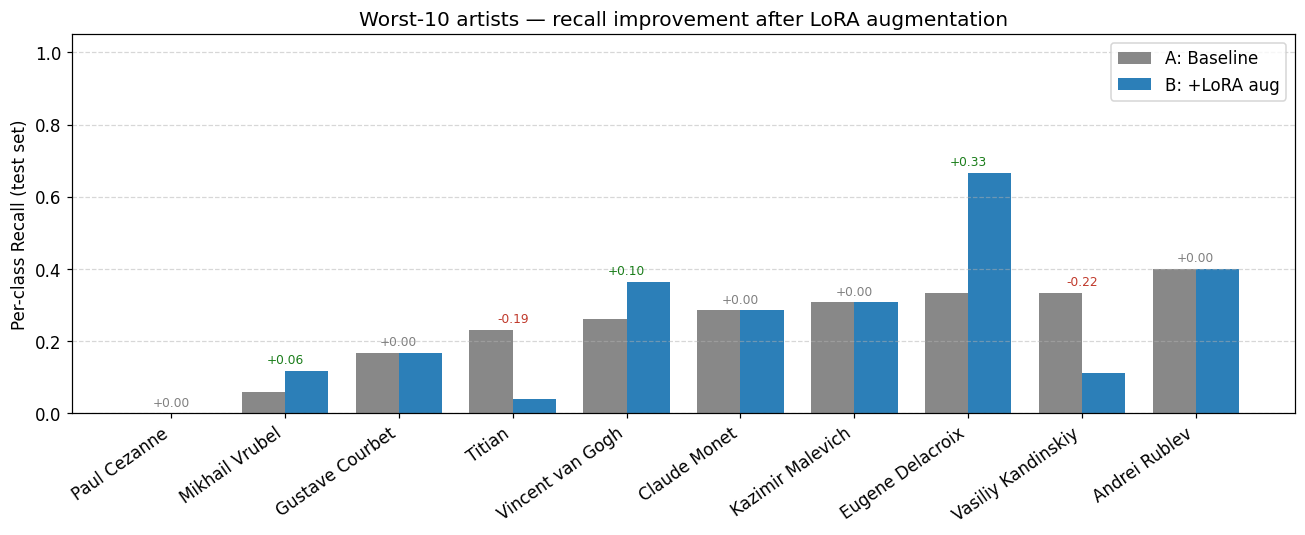

In [ ]:
# Per-artist recall for the 10 augmented painters (A vs B side-by-side)
ordered = sorted(WORST10, key=lambda c: rec_A[c])  # sort by baseline (worst first)
x = np.arange(len(ordered))
w = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
bars_A = ax.bar(x - w/2, [rec_A[c] for c in ordered], w, label='A: Baseline',  color='#888888')
bars_B = ax.bar(x + w/2, [rec_B[c] for c in ordered], w, label='B: +LoRA aug', color='#2c7fb8')
for i, c in enumerate(ordered):
    delta = rec_B[c] - rec_A[c]
    ax.text(i, max(rec_A[c], rec_B[c]) + 0.02,
            f'{delta:+.2f}', ha='center', fontsize=8,
            color='#1a7d1a' if delta > 0 else '#c0392b' if delta < 0 else 'gray')
ax.set_xticks(x); ax.set_xticklabels(ordered, rotation=35, ha='right')
ax.set_ylabel('Per-class Recall (test set)')
ax.set_title('Worst-10 artists — recall improvement after LoRA augmentation')
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

In [ ]:
# Regression check: did any of the *other 40* artists get noticeably worse?
delta_other = [(c, rec_B[c] - rec_A[c]) for c in others]
delta_other.sort(key=lambda x: x[1])
biggest_drops = delta_other[:10]
biggest_gains = delta_other[-10:][::-1]

print('=== Biggest drops in non-augmented classes (potential regression) ===')
for c, d in biggest_drops:
    print(f'  {c:<30} {rec_A[c]:.3f} → {rec_B[c]:.3f}   ({d:+.3f})')
print('\n=== Biggest gains in non-augmented classes (collateral benefit) ===')
for c, d in biggest_gains:
    print(f'  {c:<30} {rec_A[c]:.3f} → {rec_B[c]:.3f}   ({d:+.3f})')

=== Biggest drops in non-augmented classes (potential regression) ===
  Michelangelo                   0.800 → 0.600   (-0.200)
  Frida Kahlo                    0.750 → 0.583   (-0.167)
  Rembrandt                      0.577 → 0.423   (-0.154)
  Salvador Dali                  0.500 → 0.357   (-0.143)
  Henri Rousseau                 0.857 → 0.714   (-0.143)
  Piet Mondrian                  0.375 → 0.250   (-0.125)
  Raphael                        0.636 → 0.545   (-0.091)
  Edgar Degas                    0.514 → 0.457   (-0.057)
  Amedeo Modigliani              0.789 → 0.737   (-0.053)
  Rene Magritte                  0.579 → 0.526   (-0.053)

=== Biggest gains in non-augmented classes (collateral benefit) ===
  Edouard Manet                  0.444 → 0.889   (+0.444)
  Diego Velazquez                0.250 → 0.500   (+0.250)
  Pablo Picasso                  0.364 → 0.523   (+0.159)
  Sandro Botticelli              0.562 → 0.688   (+0.125)
  Henri de Toulouse-Lautrec      0.375 → 0.500   

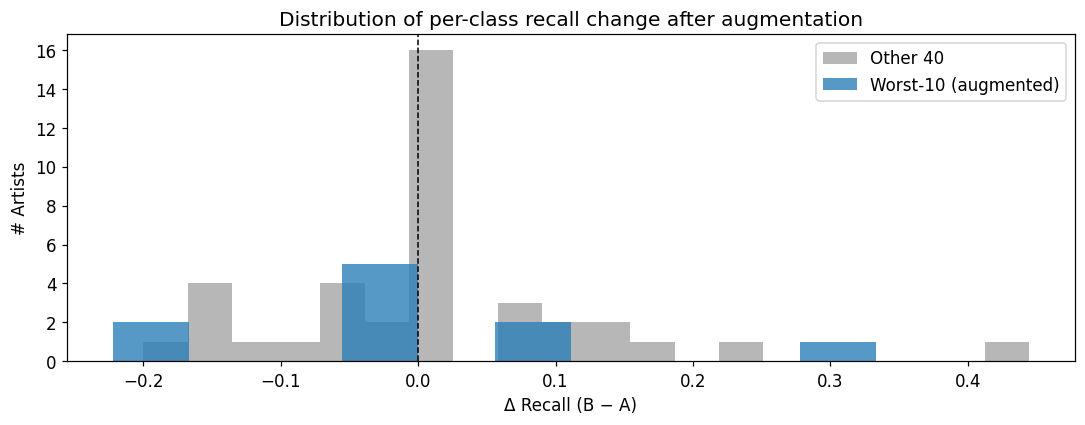

Worst-10: mean Δ = +0.0080, median Δ = +0.0000
Other 40: mean Δ = +0.0061, median Δ = +0.0000


In [ ]:
# Histogram of Δrecall across all classes — eyeball the distribution shift
deltas_all = np.array([rec_B[c] - rec_A[c] for c in le.classes_])
is_worst10 = np.array([c in WORST10 for c in le.classes_])

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(deltas_all[~is_worst10], bins=20, alpha=0.6, label='Other 40', color='#888888')
ax.hist(deltas_all[is_worst10],  bins=10, alpha=0.8, label='Worst-10 (augmented)', color='#2c7fb8')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Δ Recall (B − A)'); ax.set_ylabel('# Artists')
ax.set_title('Distribution of per-class recall change after augmentation')
ax.legend(); plt.tight_layout(); plt.show()

print(f'Worst-10: mean Δ = {deltas_all[is_worst10].mean():+.4f}, median Δ = {np.median(deltas_all[is_worst10]):+.4f}')
print(f'Other 40: mean Δ = {deltas_all[~is_worst10].mean():+.4f}, median Δ = {np.median(deltas_all[~is_worst10]):+.4f}')

In [ ]:
# Save a CSV with per-class results for the writeup
summary_df = pd.DataFrame({
    'artist':    le.classes_,
    'augmented': [c in WORST10 for c in le.classes_],
    'recall_A':  [rec_A[c] for c in le.classes_],
    'recall_B':  [rec_B[c] for c in le.classes_],
    'delta':     [rec_B[c] - rec_A[c] for c in le.classes_],
}).sort_values('delta', ascending=False)
summary_csv = os.path.join(OUT_DIR, 'lora_aug_per_class_summary.csv')
summary_df.to_csv(summary_csv, index=False)
print(f'Saved per-class summary → {summary_csv}')
summary_df.head(15)

Saved per-class summary → /content/drive/MyDrive/Colab Notebooks/209b_project/output_lora_exp/lora_aug_per_class_summary.csv


,artist,augmented,recall_A,recall_B,delta
10,Edouard Manet,False,0.444444,0.888889,0.444444
13,Eugene Delacroix,True,0.333333,0.666667,0.333333
8,Diego Velazquez,False,0.250000,0.500000,0.250000
32,Pablo Picasso,False,0.363636,0.522727,0.159091
22,Henri de Toulouse-Lautrec,False,0.375000,0.500000,0.125000
44,Sandro Botticelli,False,0.562500,0.687500,0.125000
4,Camille Pissarro,False,0.444444,0.555556,0.111111
47,Vincent van Gogh,True,0.261364,0.363636,0.102273
26,Joan Miro,False,0.700000,0.800000,0.100000
18,Gustav Klimt,False,0.416667,0.500000,0.083333


## 7. Experiment B' — Corrected sampler (real-majority within class)

**Root cause from §6**: the original sampler `weights = 1/label_counts[y_train_aug]` includes synth in the count, so worst-10 classes were sampled ~84% synthetic. The model effectively learned LoRA generation style, not real paintings.

**Fix**: per-sample weights such that *within each class*, real images get `REAL_FRAC` of the probability mass and synth gets `1 - REAL_FRAC`. Across-class balance is preserved (every class has the same total weight = 1).

- `REAL_FRAC = 1.0` → no synth ever sampled (degenerates to baseline real-only training)
- `REAL_FRAC = 0.7` → mostly real, synth as regularizer (recommended starting point)
- `REAL_FRAC = 0.5` → balanced real:synth within class
- `REAL_FRAC ≈ 0.16` (37/237) → matches original B behavior for Cezanne

In [ ]:
# ── Experiment B': corrected per-class sampler ───────────────────
# Requires: X_train_aug, y_train_aug, y_train, y_synth already defined
# (cells §2, §3, §3b above). Re-run §3b first if you want the I/O speedup.

REAL_FRAC = 0.7   # ← TUNE THIS. Fraction of in-class samples that are real.
N_EPOCHS_BP = 10

# Per-class real / synth counts
real_count_per_class  = np.bincount(y_train,  minlength=n_classes)
synth_count_per_class = np.bincount(y_synth,  minlength=n_classes)

# Per-sample weights: first len(X_train) entries are real, rest are synth
weights_corrected = np.zeros(len(X_train_aug), dtype=np.float64)
for i, lab in enumerate(y_train):
    if synth_count_per_class[lab] > 0:
        weights_corrected[i] = REAL_FRAC / real_count_per_class[lab]
    else:
        weights_corrected[i] = 1.0 / real_count_per_class[lab]
offset = len(y_train)
for j, lab in enumerate(y_synth):
    weights_corrected[offset + j] = (1.0 - REAL_FRAC) / synth_count_per_class[lab]

# Sanity: per-class total weight should be ~1 for all classes (cross-class balance)
print(f'REAL_FRAC = {REAL_FRAC}\n')
print(f'{"class":<28}{"n_real":>7}{"n_synth":>9}{"sum_w":>10}{"real_share":>13}')
for c in range(n_classes):
    mask = (y_train_aug == c)
    nr, ns = real_count_per_class[c], synth_count_per_class[c]
    w_real_sum  = weights_corrected[:offset][y_train  == c].sum()
    w_synth_sum = weights_corrected[offset:][y_synth == c].sum()
    sum_w = w_real_sum + w_synth_sum
    share = w_real_sum / sum_w if sum_w > 0 else 0
    flag = ' *' if ns > 0 else ''
    print(f'  {le.classes_[c][:25]:<26}{nr:>7}{ns:>9}{sum_w:>10.4f}{share:>13.2f}{flag}')

# Build loader (reuse train_ds_aug from §3b/§5; reuse LOADER_KW if defined)
LOADER_KW_BP = globals().get('LOADER_KW', dict(num_workers=2, pin_memory=True))
sampler_corrected = WeightedRandomSampler(weights_corrected, num_samples=len(weights_corrected), replacement=True)
train_loader_Bp = DataLoader(train_ds_aug, batch_size=32, sampler=sampler_corrected, **LOADER_KW_BP)

# Fresh model
model_Bp = build_resnet18_frozen(n_classes).to(device)
optimizer_Bp = torch.optim.Adam(model_Bp.fc.parameters(), lr=1e-3)
scheduler_Bp = torch.optim.lr_scheduler.StepLR(optimizer_Bp, step_size=3, gamma=0.5)

TAG_BP = f'resnet18_frozen_lora_aug_realfrac{REAL_FRAC:.2f}'
HIST_PATH_BP  = os.path.join(OUT_DIR, f'{TAG_BP}_history.npy')
MODEL_PATH_BP = os.path.join(OUT_DIR, f'{TAG_BP}.pt')
CKPT_PATH_BP  = os.path.join(OUT_DIR, f'{TAG_BP}_checkpoint.pt')

history_Bp = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
start_epoch_Bp = 1
if os.path.exists(CKPT_PATH_BP):
    ck = torch.load(CKPT_PATH_BP, map_location=device)
    model_Bp.load_state_dict(ck['model'])
    optimizer_Bp.load_state_dict(ck['optimizer'])
    scheduler_Bp.load_state_dict(ck['scheduler'])
    history_Bp = ck['history']
    start_epoch_Bp = ck['epoch'] + 1
    print(f'Resumed from epoch {ck["epoch"]}')

if os.path.exists(MODEL_PATH_BP) and os.path.exists(HIST_PATH_BP):
    print(f'Found previously trained B\' (realfrac={REAL_FRAC}) — loading.')
    model_Bp.load_state_dict(torch.load(MODEL_PATH_BP, map_location=device))
    history_Bp = np.load(HIST_PATH_BP, allow_pickle=True).item()
else:
    for epoch in range(start_epoch_Bp, N_EPOCHS_BP + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model_Bp, train_loader_Bp, optimizer=optimizer_Bp, train=True)
        va_loss, va_acc = run_epoch(model_Bp, val_loader,       train=False)
        scheduler_Bp.step()
        history_Bp['train_loss'].append(tr_loss); history_Bp['val_loss'].append(va_loss)
        history_Bp['train_acc'].append(tr_acc);   history_Bp['val_acc'].append(va_acc)
        print(f'Epoch {epoch:02d}/{N_EPOCHS_BP} | train {tr_loss:.3f}/{tr_acc:.3f} | '
              f'val {va_loss:.3f}/{va_acc:.3f} | {time.time()-t0:.1f}s')
        torch.save({'epoch': epoch, 'model': model_Bp.state_dict(),
                    'optimizer': optimizer_Bp.state_dict(),
                    'scheduler': scheduler_Bp.state_dict(),
                    'history': history_Bp}, CKPT_PATH_BP)
    np.save(HIST_PATH_BP, history_Bp)
    torch.save(model_Bp.state_dict(), MODEL_PATH_BP)
    if os.path.exists(CKPT_PATH_BP): os.remove(CKPT_PATH_BP)
    print(f'Saved → {MODEL_PATH_BP}')

REAL_FRAC = 0.7

class                        n_real  n_synth     sum_w   real_share
  Alfred Sisley                 207        0    1.0000         1.00
  Amedeo Modigliani             155        0    1.0000         1.00
  Andrei Rublev                  79      200    1.0000         0.70 *
  Andy Warhol                   145        0    1.0000         1.00
  Camille Pissarro               73        0    1.0000         1.00
  Caravaggio                     44        0    1.0000         1.00
  Claude Monet                   59      200    1.0000         0.70 *
  Diego Rivera                   56        0    1.0000         1.00
  Diego Velazquez                29        0    1.0000         1.00
  Edgar Degas                   562        0    1.0000         1.00
  Edouard Manet                  72        0    1.0000         1.00
  Edvard Munch                   53        0    1.0000         1.00
  El Greco                       69        0    1.0000         1.00
  Eugene Delacroix         

Epoch 01/10 | train 2.926/0.293 | val 2.490/0.357 | 24.4s


Epoch 02/10 | train 2.025/0.491 | val 2.050/0.444 | 24.2s


Epoch 03/10 | train 1.730/0.555 | val 2.024/0.441 | 25.0s


Epoch 04/10 | train 1.547/0.608 | val 1.934/0.466 | 23.3s


...

Epoch 06/10 | train 1.432/0.630 | val 1.807/0.488 | 23.6s


Epoch 07/10 | train 1.371/0.640 | val 1.850/0.479 | 24.4s


Epoch 08/10 | train 1.347/0.648 | val 1.791/0.500 | 23.7s


Epoch 09/10 | train 1.337/0.649 | val 1.808/0.499 | 24.8s


Epoch 10/10 | train 1.297/0.662 | val 1.770/0.506 | 23.6s
Saved → /content/drive/MyDrive/Colab Notebooks/209b_project/output_lora_exp/resnet18_frozen_lora_aug_realfrac0.70.pt



[B' realfrac=0.7] Test accuracy = 0.5405

                                       A         B   B prime
------------------------------------------------------------
Overall test acc                  0.5205    0.5243    0.5405
Worst-10 mean recall              0.2378    0.2458    0.3877
Other-40 mean recall              0.6421    0.6482    0.6553

WORST-10 per-class recall              A         B   B prime      Bp-A
----------------------------------------------------------------------
  Paul Cezanne                     0.000     0.000     0.200    +0.200
  Mikhail Vrubel                   0.059     0.118     0.176    +0.118
  Gustave Courbet                  0.167     0.167     0.167    +0.000
  Titian                           0.231     0.038     0.192    -0.038
  Vincent van Gogh                 0.261     0.364     0.330    +0.068
  Claude Monet                     0.286     0.286     0.571    +0.286
  Kazimir Malevich                 0.308     0.308     0.308    +0.000
  Eugene Del

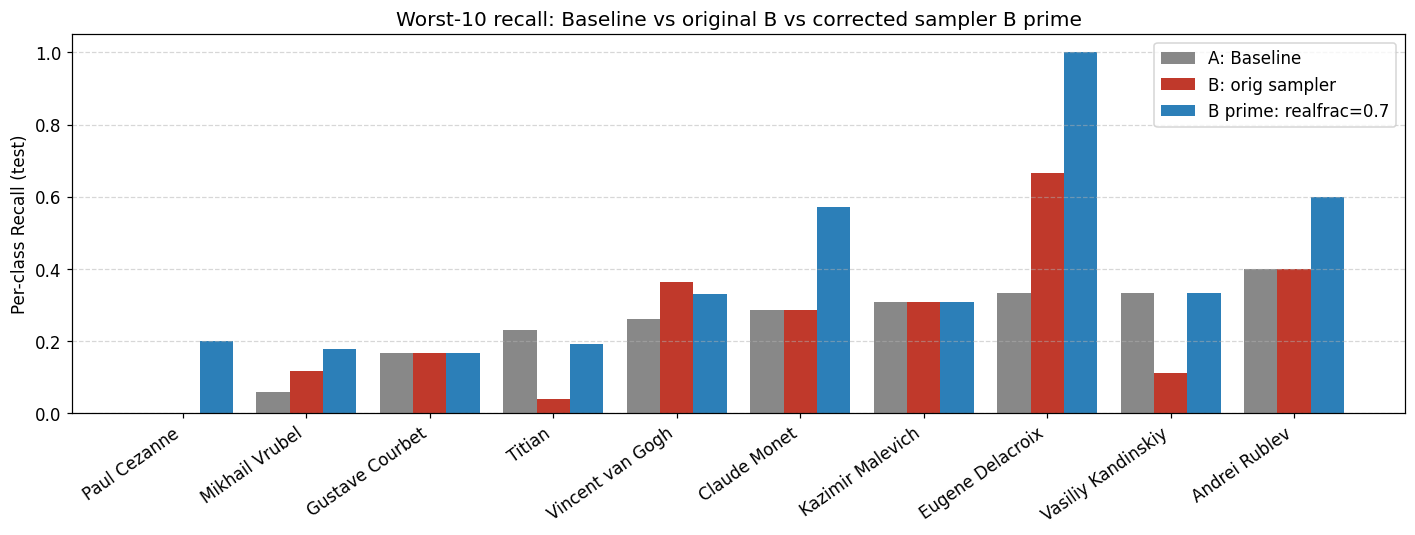

In [ ]:
# ── Evaluate B' and compare to A and B ───────────────────────────
preds_Bp, _, probs_Bp = run_inference(model_Bp, test_loader)
acc_Bp = (preds_Bp == true_test).mean()
print(f'\n[B\' realfrac={REAL_FRAC}] Test accuracy = {acc_Bp:.4f}')
np.savez(os.path.join(OUT_DIR, f'preds_Bp_realfrac{REAL_FRAC:.2f}.npz'),
         preds=preds_Bp, true=true_test, probs=probs_Bp)

# Three-way comparison
rep_Bp = classification_report(true_test, preds_Bp, target_names=le.classes_, output_dict=True, zero_division=0)
rec_Bp = {c: rep_Bp[c]['recall'] for c in le.classes_}

print(f'\n{"":<30}{"A":>10}{"B":>10}{"B prime":>10}')
print('-' * 60)
print(f'{"Overall test acc":<30}{acc_A:>10.4f}{acc_B:>10.4f}{acc_Bp:>10.4f}')
print(f'{"Worst-10 mean recall":<30}'
      f'{np.mean([rec_A[c] for c in WORST10]):>10.4f}'
      f'{np.mean([rec_B[c] for c in WORST10]):>10.4f}'
      f'{np.mean([rec_Bp[c] for c in WORST10]):>10.4f}')
others = [c for c in le.classes_ if c not in WORST10]
print(f'{"Other-40 mean recall":<30}'
      f'{np.mean([rec_A[c] for c in others]):>10.4f}'
      f'{np.mean([rec_B[c] for c in others]):>10.4f}'
      f'{np.mean([rec_Bp[c] for c in others]):>10.4f}')

# Per-artist for worst-10
print(f'\n{"WORST-10 per-class recall":<30}{"A":>10}{"B":>10}{"B prime":>10}{"Bp-A":>10}')
print('-' * 70)
for c in sorted(WORST10, key=lambda x: rec_A[x]):
    print(f'  {c:<28}{rec_A[c]:>10.3f}{rec_B[c]:>10.3f}{rec_Bp[c]:>10.3f}{rec_Bp[c]-rec_A[c]:>+10.3f}')

# Bar chart: A vs B vs B' on the 10 augmented painters
ordered = sorted(WORST10, key=lambda c: rec_A[c])
x = np.arange(len(ordered))
w = 0.27
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w, [rec_A[c]  for c in ordered], w, label='A: Baseline',         color='#888888')
ax.bar(x,     [rec_B[c]  for c in ordered], w, label='B: orig sampler',      color='#c0392b')
ax.bar(x + w, [rec_Bp[c] for c in ordered], w, label=f'B prime: realfrac={REAL_FRAC}', color='#2c7fb8')
ax.set_xticks(x); ax.set_xticklabels(ordered, rotation=35, ha='right')
ax.set_ylabel('Per-class Recall (test)')
ax.set_title('Worst-10 recall: Baseline vs original B vs corrected sampler B prime')
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

## 8. Sweep over `REAL_FRAC` — what setting gives the biggest lift?

Trains B' for several values of `REAL_FRAC`, evaluates each on the same test set, and aggregates into one comparison table + plot.

**Key checkpoints in the sweep:**
- `1.00` → **fair baseline A'** (same code/hyperparams as B', but real-only — no synth ever sampled). Resolves the unfairness in A (teammate's checkpoint, unknown setup).
- `0.70` → already trained in §7, will load from cache.
- `0.16` ≈ original B behavior (Cezanne 37/237=0.156).

Each setting saves its own `.pt` + `_history.npy` + `preds_Bp_realfrac{X}.npz` — already-trained values are loaded instantly.

In [ ]:
# ── Sweep training: train B' for each REAL_FRAC value ───────────
# Each run is ~10-15 min after §3b I/O speedup; ~10x longer without it.
# Already-trained REAL_FRAC values will load from cache (1 sec).

REAL_FRAC_SWEEP = [1.00, 0.85, 0.70, 0.50, 0.30, 0.16]
N_EPOCHS_SWEEP = 10

LOADER_KW_SW = globals().get('LOADER_KW', dict(num_workers=2, pin_memory=True))
real_count_per_class  = np.bincount(y_train, minlength=n_classes)
synth_count_per_class = np.bincount(y_synth, minlength=n_classes)

def build_weights(real_frac):
    w = np.zeros(len(X_train_aug), dtype=np.float64)
    for i, lab in enumerate(y_train):
        if synth_count_per_class[lab] > 0:
            w[i] = real_frac / real_count_per_class[lab]
        else:
            w[i] = 1.0 / real_count_per_class[lab]
    off = len(y_train)
    for j, lab in enumerate(y_synth):
        if synth_count_per_class[lab] > 0 and real_frac < 1.0:
            w[off + j] = (1.0 - real_frac) / synth_count_per_class[lab]
        else:
            w[off + j] = 0.0   # REAL_FRAC=1.0 → never sample synth
    return w

sweep_models = {}
sweep_history = {}

for rf in REAL_FRAC_SWEEP:
    tag = f'resnet18_frozen_lora_aug_realfrac{rf:.2f}'
    HIST = os.path.join(OUT_DIR, f'{tag}_history.npy')
    MDL  = os.path.join(OUT_DIR, f'{tag}.pt')
    CKPT = os.path.join(OUT_DIR, f'{tag}_checkpoint.pt')

    model_rf = build_resnet18_frozen(n_classes).to(device)

    if os.path.exists(MDL) and os.path.exists(HIST):
        model_rf.load_state_dict(torch.load(MDL, map_location=device))
        hist_rf = np.load(HIST, allow_pickle=True).item()
        print(f'[REAL_FRAC={rf:.2f}] Loaded cached model.')
    else:
        print(f'[REAL_FRAC={rf:.2f}] Training...')
        weights_rf = build_weights(rf)
        sampler_rf = WeightedRandomSampler(weights_rf, num_samples=len(weights_rf), replacement=True)
        loader_rf  = DataLoader(train_ds_aug, batch_size=32, sampler=sampler_rf, **LOADER_KW_SW)

        opt_rf   = torch.optim.Adam(model_rf.fc.parameters(), lr=1e-3)
        sched_rf = torch.optim.lr_scheduler.StepLR(opt_rf, step_size=3, gamma=0.5)
        hist_rf  = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        start = 1

        if os.path.exists(CKPT):
            ck = torch.load(CKPT, map_location=device)
            model_rf.load_state_dict(ck['model']);  opt_rf.load_state_dict(ck['optimizer'])
            sched_rf.load_state_dict(ck['scheduler']); hist_rf = ck['history']
            start = ck['epoch'] + 1
            print(f'  resumed from epoch {ck["epoch"]}')

        for epoch in range(start, N_EPOCHS_SWEEP + 1):
            t0 = time.time()
            tr_loss, tr_acc = run_epoch(model_rf, loader_rf, optimizer=opt_rf, train=True)
            va_loss, va_acc = run_epoch(model_rf, val_loader,  train=False)
            sched_rf.step()
            hist_rf['train_loss'].append(tr_loss); hist_rf['val_loss'].append(va_loss)
            hist_rf['train_acc'].append(tr_acc);   hist_rf['val_acc'].append(va_acc)
            print(f'  ep {epoch:02d} | tr {tr_loss:.3f}/{tr_acc:.3f} | va {va_loss:.3f}/{va_acc:.3f} | {time.time()-t0:.0f}s')
            torch.save({'epoch':epoch,'model':model_rf.state_dict(),'optimizer':opt_rf.state_dict(),
                        'scheduler':sched_rf.state_dict(),'history':hist_rf}, CKPT)
        np.save(HIST, hist_rf); torch.save(model_rf.state_dict(), MDL)
        if os.path.exists(CKPT): os.remove(CKPT)

    sweep_models[rf]  = model_rf
    sweep_history[rf] = hist_rf

print(f'\nDone. {len(sweep_models)} models ready: REAL_FRAC = {list(sweep_models.keys())}')

[REAL_FRAC=1.00] Training...


  ep 01 | tr 2.898/0.288 | va 2.476/0.359 | 19s


  ep 02 | tr 1.968/0.509 | va 2.111/0.446 | 19s


  ep 03 | tr 1.666/0.570 | va 1.989/0.459 | 19s


  ep 04 | tr 1.490/0.622 | va 1.911/0.476 | 19s


...

  ep 06 | tr 1.343/0.652 | va 2.082/0.466 | 32s


  ep 07 | tr 1.268/0.677 | va 1.995/0.464 | 33s


  ep 08 | tr 1.259/0.677 | va 2.040/0.474 | 32s


  ep 09 | tr 1.222/0.690 | va 2.067/0.458 | 32s


  ep 10 | tr 1.207/0.691 | va 2.008/0.458 | 32s

Done. 6 models ready: REAL_FRAC = [1.0, 0.85, 0.7, 0.5, 0.3, 0.16]


                    setting  real_frac  overall_acc  worst10_mean_recall  other40_mean_recall
        A_baseline_teammate        NaN       0.5205               0.2378               0.6421
             B_orig_sampler        NaN       0.5243               0.2458               0.6482
Bp_realfrac_1.00 (= A_fair)     1.0000       0.5230               0.2950               0.6348
           Bp_realfrac_0.85     0.8500       0.5430               0.3109               0.6563
           Bp_realfrac_0.70     0.7000       0.5405               0.3877               0.6553
           Bp_realfrac_0.50     0.5000       0.5193               0.2848               0.6520
           Bp_realfrac_0.30     0.3000       0.5168               0.2796               0.6588
           Bp_realfrac_0.16     0.1600       0.5255               0.2034               0.6805

Saved → /content/drive/MyDrive/Colab Notebooks/209b_project/output_lora_exp/sweep_summary.csv


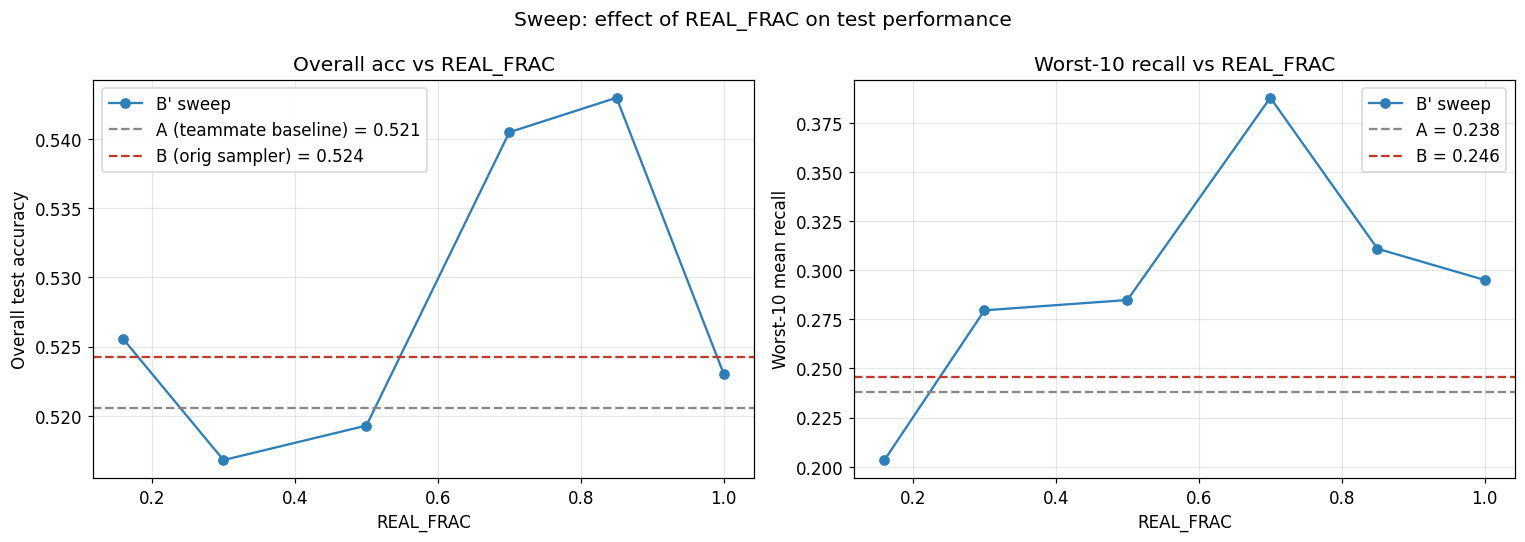


=== Worst-10 per-class recall, all settings ===
                        A  B(orig)  Bp(1.00)  Bp(0.85)  Bp(0.70)  Bp(0.50)  Bp(0.30)  Bp(0.16)
Andrei Rublev       0.400    0.400     0.400     0.500     0.600     0.500     0.400     0.300
Claude Monet        0.286    0.286     0.571     0.429     0.571     0.286     0.286     0.286
Eugene Delacroix    0.333    0.667     0.333     0.333     1.000     1.000     1.000     0.667
Gustave Courbet     0.167    0.167     0.333     0.333     0.167     0.167     0.167     0.167
Kazimir Malevich    0.308    0.308     0.385     0.308     0.308     0.308     0.308     0.231
Mikhail Vrubel      0.059    0.118     0.118     0.176     0.176     0.000     0.059     0.000
Paul Cezanne        0.000    0.000     0.000     0.200     0.200     0.200     0.200     0.000
Titian              0.231    0.038     0.269     0.423     0.192     0.115     0.038     0.000
Vasiliy Kandinskiy  0.333    0.111     0.222     0.111     0.333     0.000     0.111     0.111
V

In [ ]:
# ── Aggregate sweep results: A vs B vs all REAL_FRAC values ─────
from sklearn.metrics import classification_report

# Evaluate each model on the same test set
sweep_preds = {}
for rf, m in sweep_models.items():
    p, _, pr = run_inference(m, test_loader)
    sweep_preds[rf] = p
    np.savez(os.path.join(OUT_DIR, f'preds_Bp_realfrac{rf:.2f}.npz'),
             preds=p, true=true_test, probs=pr)

def per_class_recall(preds, true):
    return {le.classes_[c]: ((preds[true==c]==c).mean() if (true==c).sum() else float('nan'))
            for c in range(n_classes)}

# Build summary DataFrame
rows = []
# Add A and B for reference (already evaluated; just compute aggregates)
for label, preds_arr in [('A_baseline_teammate', preds_A), ('B_orig_sampler', preds_B)]:
    rec = per_class_recall(preds_arr, true_test)
    rows.append({
        'setting': label,
        'real_frac': None,
        'overall_acc': (preds_arr == true_test).mean(),
        'worst10_mean_recall':  np.mean([rec[c] for c in WORST10]),
        'other40_mean_recall':  np.mean([rec[c] for c in [c for c in le.classes_ if c not in WORST10]]),
    })
for rf in sorted(sweep_preds.keys(), reverse=True):
    rec = per_class_recall(sweep_preds[rf], true_test)
    label = "Bp_realfrac_1.00 (= A_fair)" if rf == 1.0 else f"Bp_realfrac_{rf:.2f}"
    rows.append({
        'setting': label,
        'real_frac': rf,
        'overall_acc': (sweep_preds[rf] == true_test).mean(),
        'worst10_mean_recall':  np.mean([rec[c] for c in WORST10]),
        'other40_mean_recall':  np.mean([rec[c] for c in [c for c in le.classes_ if c not in WORST10]]),
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))
summary.to_csv(os.path.join(OUT_DIR, 'sweep_summary.csv'), index=False)
print(f'\nSaved → {OUT_DIR}/sweep_summary.csv')

# Plot: metric vs REAL_FRAC (with A and B as horizontal references)
sw = summary[summary['real_frac'].notna()].sort_values('real_frac')
A_acc, B_acc = summary.iloc[0]['overall_acc'], summary.iloc[1]['overall_acc']
A_w10, B_w10 = summary.iloc[0]['worst10_mean_recall'], summary.iloc[1]['worst10_mean_recall']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(sw['real_frac'], sw['overall_acc'], 'o-', color='#2c7fb8', label="B' sweep")
axes[0].axhline(A_acc, color='#888', linestyle='--', label=f'A (teammate baseline) = {A_acc:.3f}')
axes[0].axhline(B_acc, color='#c0392b', linestyle='--', label=f'B (orig sampler) = {B_acc:.3f}')
axes[0].set_xlabel('REAL_FRAC'); axes[0].set_ylabel('Overall test accuracy')
axes[0].set_title('Overall acc vs REAL_FRAC'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(sw['real_frac'], sw['worst10_mean_recall'], 'o-', color='#2c7fb8', label="B' sweep")
axes[1].axhline(A_w10, color='#888', linestyle='--', label=f'A = {A_w10:.3f}')
axes[1].axhline(B_w10, color='#c0392b', linestyle='--', label=f'B = {B_w10:.3f}')
axes[1].set_xlabel('REAL_FRAC'); axes[1].set_ylabel('Worst-10 mean recall')
axes[1].set_title('Worst-10 recall vs REAL_FRAC'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle("Sweep: effect of REAL_FRAC on test performance")
plt.tight_layout(); plt.show()

# Per-class worst-10 recall heatmap-style table
rec_by_setting = {}
rec_by_setting['A']          = per_class_recall(preds_A, true_test)
rec_by_setting['B(orig)']    = per_class_recall(preds_B, true_test)
for rf in sorted(sweep_preds.keys(), reverse=True):
    rec_by_setting[f'Bp({rf:.2f})'] = per_class_recall(sweep_preds[rf], true_test)

per_class_df = pd.DataFrame({k: [rec_by_setting[k][c] for c in WORST10] for k in rec_by_setting},
                             index=WORST10)
per_class_df.loc['MEAN'] = per_class_df.mean()
print('\n=== Worst-10 per-class recall, all settings ===')
print(per_class_df.round(3).to_string())
per_class_df.to_csv(os.path.join(OUT_DIR, 'sweep_worst10_per_class.csv'))
print(f'\nSaved → {OUT_DIR}/sweep_worst10_per_class.csv')

# Identify best setting by worst-10 recall
best = sw.loc[sw['worst10_mean_recall'].idxmax()]
print(f'\n>>> Best worst-10 mean recall: REAL_FRAC={best["real_frac"]:.2f} → {best["worst10_mean_recall"]:.4f}')
print(f'>>> Best overall acc:         REAL_FRAC={sw.loc[sw["overall_acc"].idxmax(), "real_frac"]:.2f} → {sw["overall_acc"].max():.4f}')

## 9. Canny+ControlNet synth comparison (B'_Canny @ REAL_FRAC=0.70)

Same pipeline as §7/§8, but with Canny+ControlNet-generated synth instead of LoRA. Single training run at the sweep's best `REAL_FRAC` (0.70 for worst-10 recall), so we can answer: *does generation method matter when sampling is controlled?*

- Canny dir: `lora_worst10_all/generated_lora_canny/<artist_lowercase>/gen_*.png` (200 per artist)
- `_canny/` subdir holds the ControlNet edge maps used as input — we skip them.
- Direct head-to-head: A vs B'_LoRA(0.70) vs B'_Canny(0.70).

In [ ]:
# ── Load Canny synth & train B'_Canny at REAL_FRAC=0.70 ─────────
CANNY_DIR = os.path.join(PROJECT_DIR, 'lora_worst10_all', 'generated_lora_canny')
REAL_FRAC_CANNY = 0.70
N_EPOCHS_CANNY = 10

X_synth_canny, y_synth_canny = [], []
canny_per_artist = {}
for folder in sorted(os.listdir(CANNY_DIR)):
    full = os.path.join(CANNY_DIR, folder)
    if not os.path.isdir(full):
        continue
    name_key = lower_to_namekey.get(folder.lower())
    if name_key is None:
        continue
    display_name = name_key_to_name[name_key]
    if display_name not in le.classes_:
        continue
    label = le.transform([display_name])[0]
    imgs = [f for f in os.listdir(full)
            if f.lower().endswith('.png') and os.path.isfile(os.path.join(full, f))]
    for f in imgs:
        X_synth_canny.append(os.path.join(full, f))
        y_synth_canny.append(label)
    canny_per_artist[display_name] = len(imgs)
y_synth_canny = np.array(y_synth_canny)
print(f'Loaded {len(X_synth_canny)} Canny synth images, {len(canny_per_artist)} artists')
for name, n in canny_per_artist.items():
    print(f'  {name:<25} {n}')

# Cache to /content/ if §3b's helper is around
if 'LOCAL_CACHE' in globals() and Path(LOCAL_CACHE).exists():
    print('\nCaching Canny synth to /content/ (matches §3b I/O speedup)...')
    X_synth_canny = [_local_path(p) for p in tqdm(X_synth_canny, desc='copy', leave=False)]

X_train_aug_canny = list(X_train) + list(X_synth_canny)
y_train_aug_canny = np.concatenate([y_train, y_synth_canny])
train_ds_aug_canny = ArtDataset(X_train_aug_canny, y_train_aug_canny, train_tf)

canny_count_per_class = np.bincount(y_synth_canny, minlength=n_classes)

weights_canny = np.zeros(len(X_train_aug_canny), dtype=np.float64)
for i, lab in enumerate(y_train):
    if canny_count_per_class[lab] > 0:
        weights_canny[i] = REAL_FRAC_CANNY / real_count_per_class[lab]
    else:
        weights_canny[i] = 1.0 / real_count_per_class[lab]
offset = len(y_train)
for j, lab in enumerate(y_synth_canny):
    weights_canny[offset + j] = (1.0 - REAL_FRAC_CANNY) / canny_count_per_class[lab]

sampler_canny = WeightedRandomSampler(weights_canny, num_samples=len(weights_canny), replacement=True)
LOADER_KW_C = globals().get('LOADER_KW', dict(num_workers=2, pin_memory=True))
train_loader_canny = DataLoader(train_ds_aug_canny, batch_size=32, sampler=sampler_canny, **LOADER_KW_C)

model_canny = build_resnet18_frozen(n_classes).to(device)
opt_c   = torch.optim.Adam(model_canny.fc.parameters(), lr=1e-3)
sched_c = torch.optim.lr_scheduler.StepLR(opt_c, step_size=3, gamma=0.5)

TAG_C  = f'resnet18_frozen_canny_aug_realfrac{REAL_FRAC_CANNY:.2f}'
HIST_C = os.path.join(OUT_DIR, f'{TAG_C}_history.npy')
MDL_C  = os.path.join(OUT_DIR, f'{TAG_C}.pt')
CKPT_C = os.path.join(OUT_DIR, f'{TAG_C}_checkpoint.pt')

hist_c = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
start_c = 1
if os.path.exists(CKPT_C):
    ck = torch.load(CKPT_C, map_location=device)
    model_canny.load_state_dict(ck['model']); opt_c.load_state_dict(ck['optimizer'])
    sched_c.load_state_dict(ck['scheduler']); hist_c = ck['history']
    start_c = ck['epoch'] + 1
    print(f'\nResumed from epoch {ck["epoch"]}')

if os.path.exists(MDL_C) and os.path.exists(HIST_C):
    print(f'\nFound previously trained Canny model — loading.')
    model_canny.load_state_dict(torch.load(MDL_C, map_location=device))
    hist_c = np.load(HIST_C, allow_pickle=True).item()
else:
    print(f'\nTraining Canny model (REAL_FRAC={REAL_FRAC_CANNY})...')
    for epoch in range(start_c, N_EPOCHS_CANNY + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model_canny, train_loader_canny, optimizer=opt_c, train=True)
        va_loss, va_acc = run_epoch(model_canny, val_loader, train=False)
        sched_c.step()
        hist_c['train_loss'].append(tr_loss); hist_c['val_loss'].append(va_loss)
        hist_c['train_acc'].append(tr_acc);   hist_c['val_acc'].append(va_acc)
        print(f'  ep {epoch:02d} | tr {tr_loss:.3f}/{tr_acc:.3f} | va {va_loss:.3f}/{va_acc:.3f} | {time.time()-t0:.0f}s')
        torch.save({'epoch':epoch,'model':model_canny.state_dict(),'optimizer':opt_c.state_dict(),
                    'scheduler':sched_c.state_dict(),'history':hist_c}, CKPT_C)
    np.save(HIST_C, hist_c); torch.save(model_canny.state_dict(), MDL_C)
    if os.path.exists(CKPT_C): os.remove(CKPT_C)
print(f'Done → {MDL_C}')

Loaded 2000 Canny synth images, 10 artists
  Andrei Rublev             200
  Claude Monet              200
  Eugene Delacroix          200
  Gustave Courbet           200
  Kazimir Malevich          200
  Mikhail Vrubel            200
  Paul Cezanne              200
  Titian                    200
  Vasiliy Kandinskiy        200
  Vincent van Gogh          200

Caching Canny synth to /content/ (matches §3b I/O speedup)...



Training Canny model (REAL_FRAC=0.7)...


  ep 01 | tr 2.902/0.287 | va 2.598/0.307 | 25s


  ep 02 | tr 1.987/0.503 | va 2.208/0.414 | 24s


  ep 03 | tr 1.687/0.562 | va 2.062/0.455 | 25s


...

  ep 06 | tr 1.377/0.639 | va 1.904/0.476 | 25s


  ep 07 | tr 1.335/0.650 | va 1.868/0.489 | 24s


  ep 08 | tr 1.322/0.658 | va 1.814/0.520 | 24s


  ep 09 | tr 1.292/0.659 | va 1.782/0.512 | 24s


  ep 10 | tr 1.267/0.669 | va 1.838/0.495 | 25s
Done → /content/drive/MyDrive/Colab Notebooks/209b_project/output_lora_exp/resnet18_frozen_canny_aug_realfrac0.70.pt


[B'_Canny REAL_FRAC=0.7] Test accuracy = 0.5318

                                       A   B(orig)   Bp_LoRA  Bp_Canny
----------------------------------------------------------------------
Overall test acc                  0.5205    0.5243    0.5405    0.5318
Worst-10 mean recall              0.2378    0.2458    0.3877    0.2810
Other-40 mean recall              0.6421    0.6482    0.6553    0.6735

WORST-10                            A     LoRA    Canny      C-L      L-A      C-A
--------------------------------------------------------------------------------
  Paul Cezanne                  0.000    0.200    0.000   -0.200   +0.200   +0.000
  Mikhail Vrubel                0.059    0.176    0.235   +0.059   +0.118   +0.176
  Gustave Courbet               0.167    0.167    0.333   +0.167   +0.000   +0.167
  Titian                        0.231    0.192    0.077   -0.115   -0.038   -0.154
  Vincent van Gogh              0.261    0.330    0.250   -0.080   +0.068   -0.011
  Claude Monet  

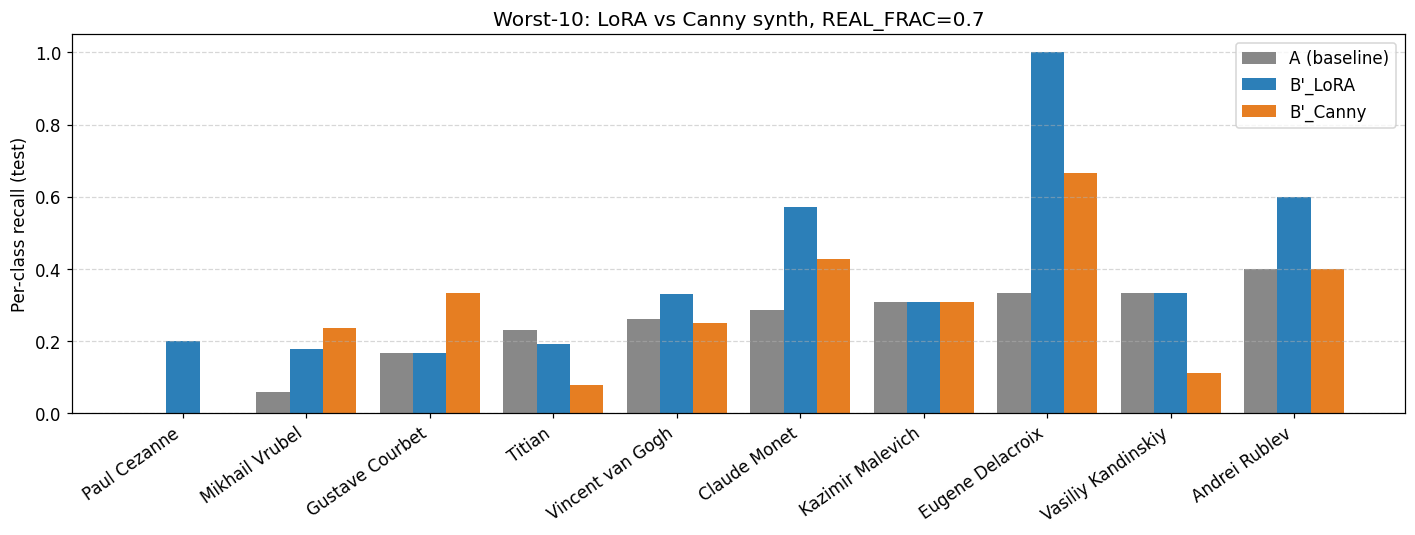


Saved → /content/drive/MyDrive/Colab Notebooks/209b_project/output_lora_exp/lora_vs_canny_per_artist.csv


In [ ]:
# ── Evaluate Canny model & compare LoRA vs Canny head-to-head ────
preds_C, _, probs_C = run_inference(model_canny, test_loader)
acc_C = (preds_C == true_test).mean()
np.savez(os.path.join(OUT_DIR, f'preds_Bp_canny_realfrac{REAL_FRAC_CANNY:.2f}.npz'),
         preds=preds_C, true=true_test, probs=probs_C)
print(f'[B\'_Canny REAL_FRAC={REAL_FRAC_CANNY}] Test accuracy = {acc_C:.4f}')

LORA_NPZ = os.path.join(OUT_DIR, f'preds_Bp_realfrac{REAL_FRAC_CANNY:.2f}.npz')
preds_Lora = np.load(LORA_NPZ)['preds']

def pcr(preds, true):
    return {le.classes_[c]: ((preds[true==c]==c).mean() if (true==c).sum() else float('nan'))
            for c in range(n_classes)}
rec_A_ = pcr(preds_A, true_test); rec_B_ = pcr(preds_B, true_test)
rec_L  = pcr(preds_Lora, true_test); rec_C = pcr(preds_C, true_test)

others = [c for c in le.classes_ if c not in WORST10]
print(f'\n{"":<30}{"A":>10}{"B(orig)":>10}{"Bp_LoRA":>10}{"Bp_Canny":>10}')
print('-' * 70)
print(f'{"Overall test acc":<30}'
      f'{(preds_A==true_test).mean():>10.4f}{(preds_B==true_test).mean():>10.4f}'
      f'{(preds_Lora==true_test).mean():>10.4f}{acc_C:>10.4f}')
print(f'{"Worst-10 mean recall":<30}'
      f'{np.mean([rec_A_[c] for c in WORST10]):>10.4f}'
      f'{np.mean([rec_B_[c] for c in WORST10]):>10.4f}'
      f'{np.mean([rec_L[c]  for c in WORST10]):>10.4f}'
      f'{np.mean([rec_C[c]  for c in WORST10]):>10.4f}')
print(f'{"Other-40 mean recall":<30}'
      f'{np.mean([rec_A_[c] for c in others]):>10.4f}'
      f'{np.mean([rec_B_[c] for c in others]):>10.4f}'
      f'{np.mean([rec_L[c]  for c in others]):>10.4f}'
      f'{np.mean([rec_C[c]  for c in others]):>10.4f}')

print(f'\n{"WORST-10":<28}{"A":>9}{"LoRA":>9}{"Canny":>9}{"C-L":>9}{"L-A":>9}{"C-A":>9}')
print('-' * 80)
for c in sorted(WORST10, key=lambda x: rec_A_[x]):
    print(f'  {c:<26}{rec_A_[c]:>9.3f}{rec_L[c]:>9.3f}{rec_C[c]:>9.3f}'
          f'{rec_C[c]-rec_L[c]:>+9.3f}{rec_L[c]-rec_A_[c]:>+9.3f}{rec_C[c]-rec_A_[c]:>+9.3f}')

ordered = sorted(WORST10, key=lambda c: rec_A_[c])
x = np.arange(len(ordered)); w = 0.27
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w, [rec_A_[c] for c in ordered], w, label='A (baseline)', color='#888888')
ax.bar(x,     [rec_L[c]  for c in ordered], w, label="B'_LoRA",      color='#2c7fb8')
ax.bar(x + w, [rec_C[c]  for c in ordered], w, label="B'_Canny",     color='#e67e22')
ax.set_xticks(x); ax.set_xticklabels(ordered, rotation=35, ha='right')
ax.set_ylabel('Per-class recall (test)')
ax.set_title(f'Worst-10: LoRA vs Canny synth, REAL_FRAC={REAL_FRAC_CANNY}')
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

comp_df = pd.DataFrame({
    'artist': WORST10,
    'recall_A':    [rec_A_[c] for c in WORST10],
    'recall_LoRA': [rec_L[c]  for c in WORST10],
    'recall_Canny':[rec_C[c]  for c in WORST10],
    'canny_minus_lora': [rec_C[c]-rec_L[c] for c in WORST10],
    'lora_minus_A':     [rec_L[c]-rec_A_[c] for c in WORST10],
    'canny_minus_A':    [rec_C[c]-rec_A_[c] for c in WORST10],
})
comp_csv = os.path.join(OUT_DIR, 'lora_vs_canny_per_artist.csv')
comp_df.to_csv(comp_csv, index=False)
print(f'\nSaved → {comp_csv}')

## 10. Report figures (all plots in one place)

Re-derived from saved `.npz` / `_history.npy` files, so this cell is idempotent and doesn't depend on session state. Each subsection produces one figure suitable for the writeup.

=== FIGURE 1: Headline four-way comparison ===


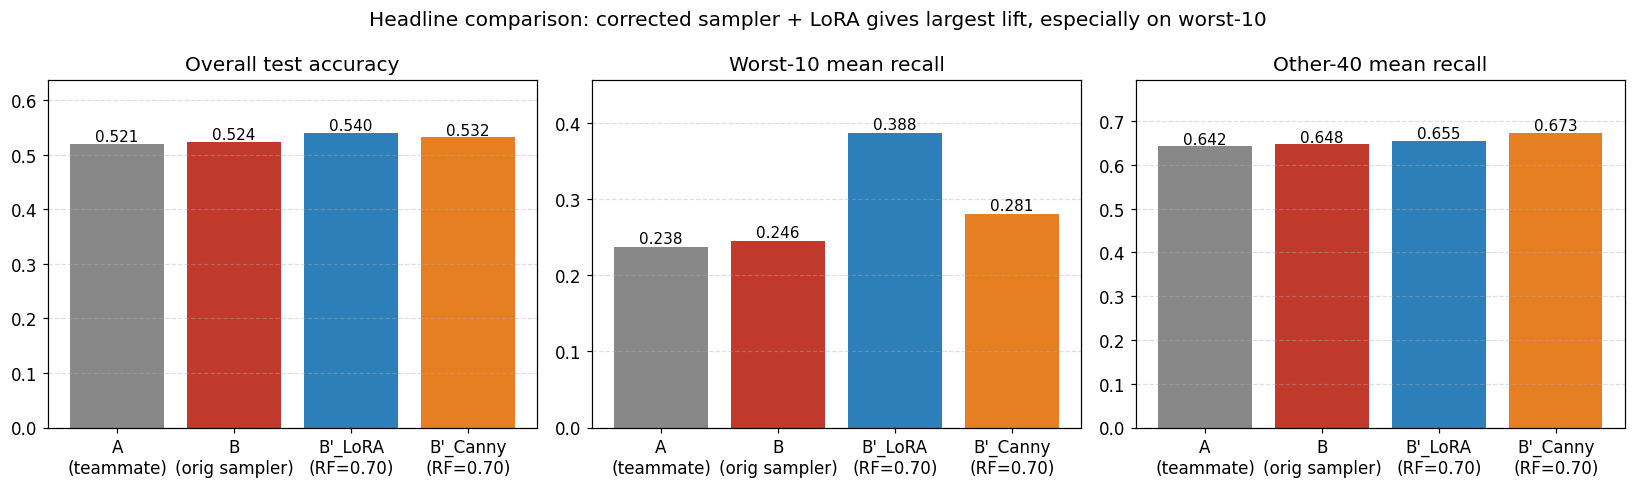


=== FIGURE 2: REAL_FRAC sweep + Canny overlay ===


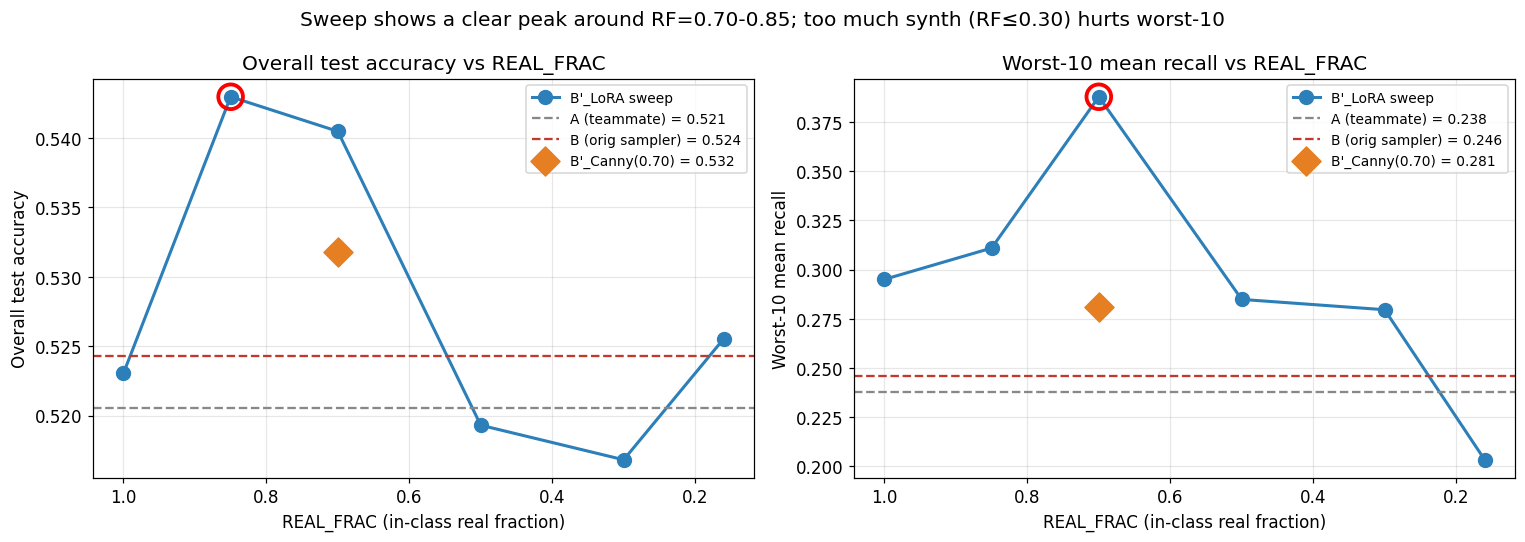


=== FIGURE 3: Worst-10 per-class heatmap ===


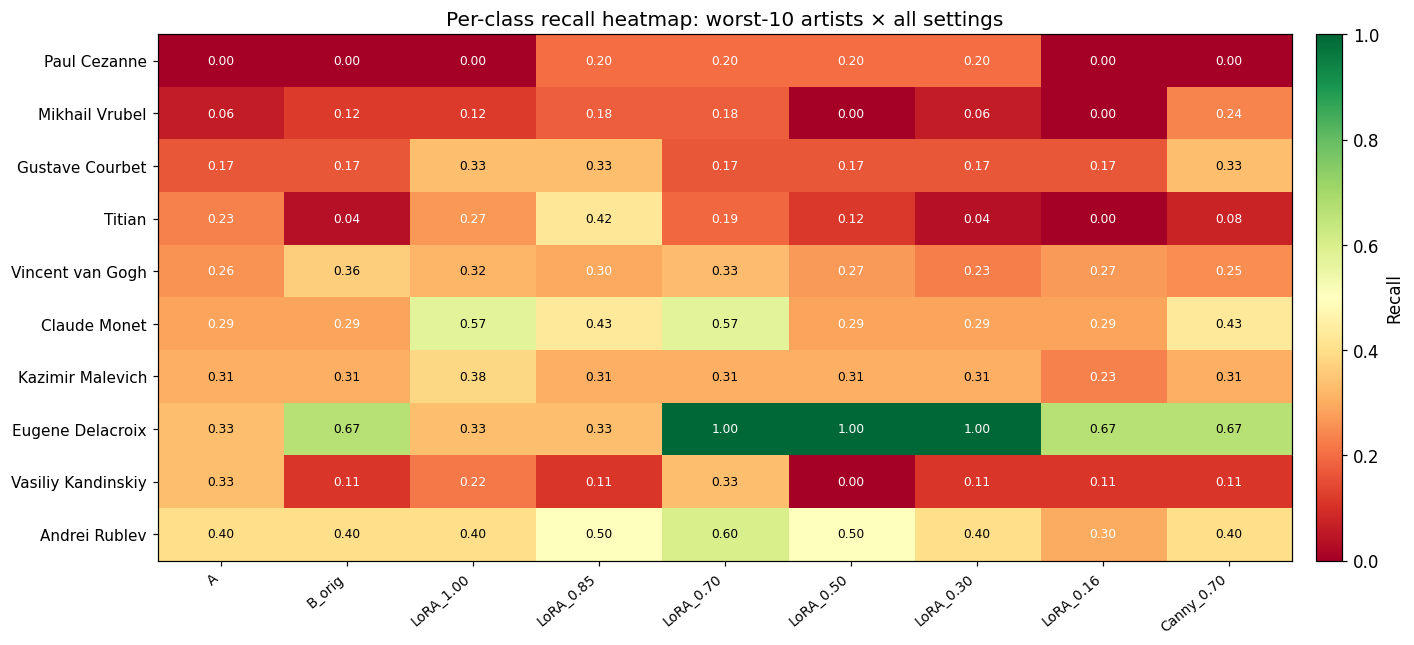


=== FIGURE 4: Train-val gap shows synth-induced overfitting ===


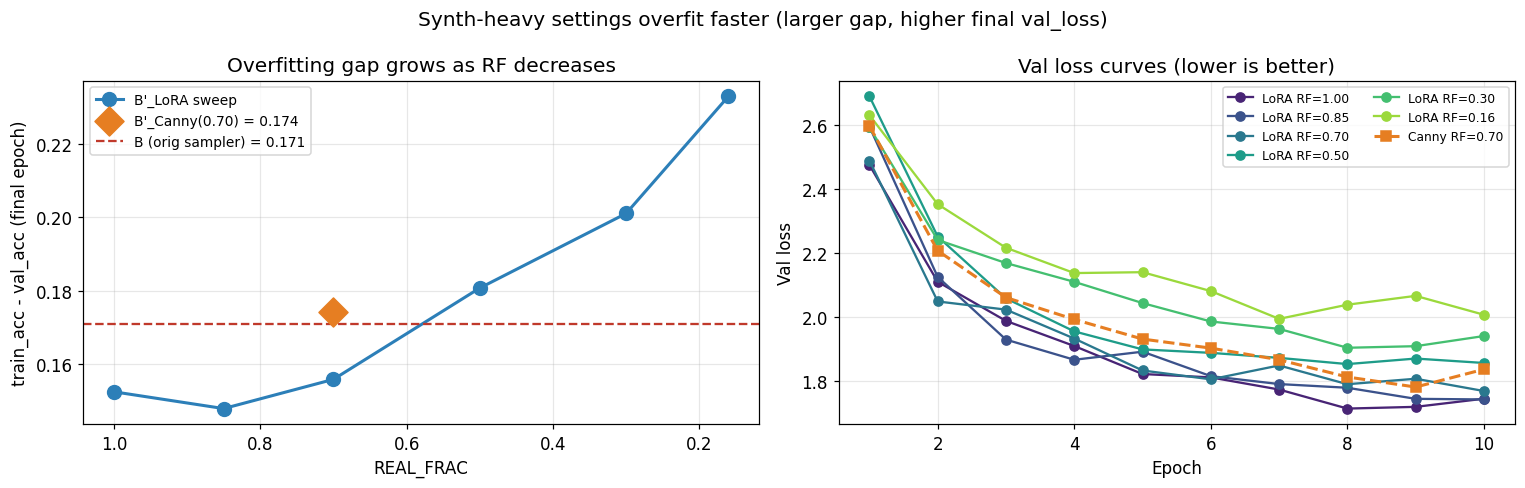


=== FIGURE 5: LoRA vs Canny per-artist (signed delta vs A) ===


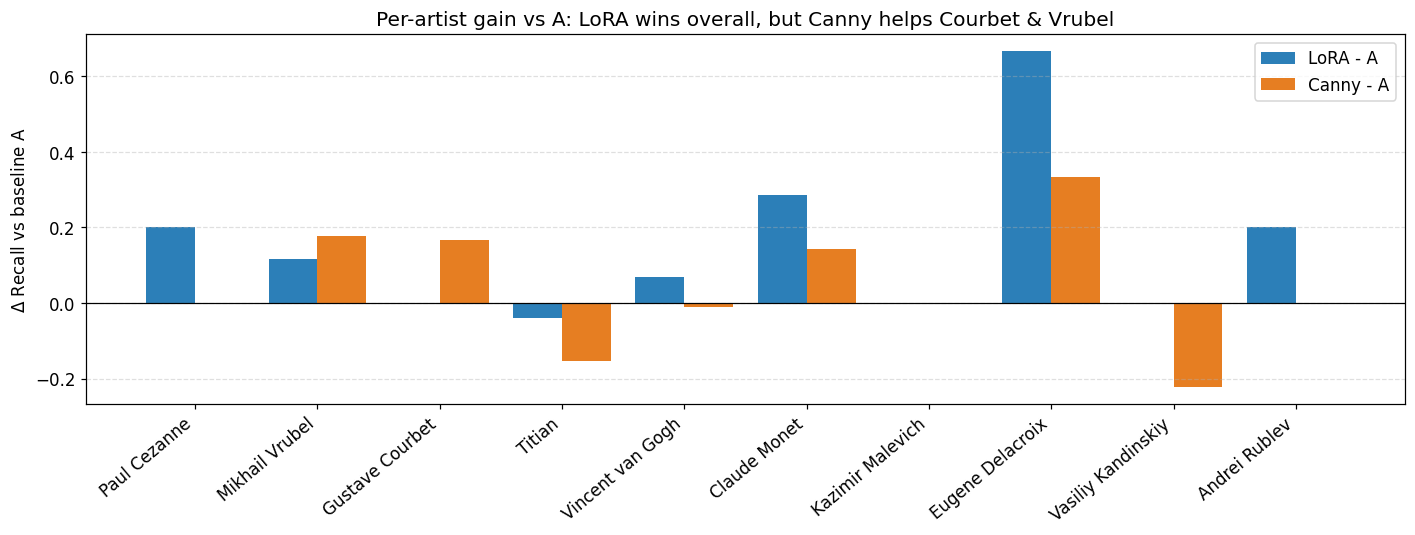


All 5 figures saved to /content/drive/MyDrive/Colab Notebooks/209b_project/output_lora_exp/fig*.png


In [ ]:
# ── Re-load everything from disk so this cell stands alone ───
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os
from matplotlib.patches import Patch

OUT = OUT_DIR
A_npz  = np.load(os.path.join(OUT, 'preds_A_baseline.npz'))
B_npz  = np.load(os.path.join(OUT, 'preds_B_augmented.npz'))
true_t = A_npz['true']

RF_LIST = [1.00, 0.85, 0.70, 0.50, 0.30, 0.16]
preds_rf = {rf: np.load(os.path.join(OUT, f'preds_Bp_realfrac{rf:.2f}.npz'))['preds'] for rf in RF_LIST}
preds_canny = np.load(os.path.join(OUT, 'preds_Bp_canny_realfrac0.70.npz'))['preds']

def pcr(preds): return np.array([(preds[true_t==c]==c).mean() if (true_t==c).sum() else np.nan for c in range(n_classes)])
def overall(preds): return (preds == true_t).mean()
def worst10(preds, idx): return np.nanmean(pcr(preds)[idx])
def other40(preds, idx_w): return np.nanmean(np.delete(pcr(preds), idx_w))

w10_idx = le.transform(WORST10)

# ── FIGURE 1: Headline 4-way bar chart (3 metrics) ─────────────
print('=== FIGURE 1: Headline four-way comparison ===')
labels = ['A\n(teammate)', 'B\n(orig sampler)', "B'_LoRA\n(RF=0.70)", "B'_Canny\n(RF=0.70)"]
runs   = [A_npz['preds'], B_npz['preds'], preds_rf[0.70], preds_canny]
colors = ['#888888', '#c0392b', '#2c7fb8', '#e67e22']
ov  = [overall(p)        for p in runs]
w10 = [worst10(p, w10_idx) for p in runs]
o40 = [other40(p, w10_idx) for p in runs]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, vals, title in zip(axes, [ov, w10, o40],
                            ['Overall test accuracy', 'Worst-10 mean recall', 'Other-40 mean recall']):
    bars = ax.bar(labels, vals, color=colors)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}', ha='center', fontsize=10)
    ax.set_title(title); ax.set_ylim(0, max(vals)*1.18); ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.suptitle('Headline comparison: corrected sampler + LoRA gives largest lift, especially on worst-10')
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'fig1_headline.png'), dpi=140, bbox_inches='tight')
plt.show()

# ── FIGURE 2: REAL_FRAC sweep curves with Canny overlay ─────────
print('\n=== FIGURE 2: REAL_FRAC sweep + Canny overlay ===')
ov_rf  = [overall(preds_rf[rf]) for rf in RF_LIST]
w10_rf = [worst10(preds_rf[rf], w10_idx) for rf in RF_LIST]
ov_C, w10_C = overall(preds_canny), worst10(preds_canny, w10_idx)
A_ov, B_ov = overall(A_npz['preds']), overall(B_npz['preds'])
A_w10, B_w10 = worst10(A_npz['preds'], w10_idx), worst10(B_npz['preds'], w10_idx)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ys, title, yA, yB, yC in [(axes[0], ov_rf, 'Overall test accuracy', A_ov, B_ov, ov_C),
                                    (axes[1], w10_rf, 'Worst-10 mean recall', A_w10, B_w10, w10_C)]:
    ax.plot(RF_LIST, ys, 'o-', color='#2c7fb8', lw=2, markersize=9, label="B'_LoRA sweep")
    ax.axhline(yA, color='#888', linestyle='--', label=f'A (teammate) = {yA:.3f}')
    ax.axhline(yB, color='#c0392b', linestyle='--', label=f'B (orig sampler) = {yB:.3f}')
    ax.scatter([0.70], [yC], color='#e67e22', s=180, zorder=5, marker='D', label=f"B'_Canny(0.70) = {yC:.3f}")
    # mark the peak
    peak_i = int(np.argmax(ys)); ax.scatter([RF_LIST[peak_i]], [ys[peak_i]], facecolors='none',
                                              edgecolors='red', s=260, lw=2.5, zorder=6)
    ax.set_xlabel('REAL_FRAC (in-class real fraction)'); ax.set_ylabel(title)
    ax.set_title(title + ' vs REAL_FRAC')
    ax.invert_xaxis()   # left = 1.0 (no synth), right = 0.16 (most synth)
    ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='best')
plt.suptitle('Sweep shows a clear peak around RF=0.70-0.85; too much synth (RF≤0.30) hurts worst-10')
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'fig2_sweep.png'), dpi=140, bbox_inches='tight')
plt.show()

# ── FIGURE 3: Worst-10 per-class heatmap across all settings ────
print('\n=== FIGURE 3: Worst-10 per-class heatmap ===')
settings = ['A', 'B_orig'] + [f'LoRA_{rf:.2f}' for rf in RF_LIST] + ['Canny_0.70']
all_preds = [A_npz['preds'], B_npz['preds']] + [preds_rf[rf] for rf in RF_LIST] + [preds_canny]

mat = np.zeros((len(WORST10), len(settings)))
ordered = sorted(WORST10, key=lambda c: pcr(A_npz['preds'])[le.transform([c])[0]])
for i, c in enumerate(ordered):
    cidx = le.transform([c])[0]
    for j, p in enumerate(all_preds):
        mat[i, j] = pcr(p)[cidx]

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(settings))); ax.set_xticklabels(settings, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(ordered))); ax.set_yticklabels(ordered, fontsize=10)
for i in range(len(ordered)):
    for j in range(len(settings)):
        v = mat[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                color='black' if 0.3 < v < 0.85 else 'white')
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='Recall')
ax.set_title('Per-class recall heatmap: worst-10 artists × all settings')
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'fig3_heatmap.png'), dpi=140, bbox_inches='tight')
plt.show()

# ── FIGURE 4: Overfitting analysis (train-val gap) ──────────────
print('\n=== FIGURE 4: Train-val gap shows synth-induced overfitting ===')
gaps = []; final_val_loss = []; min_val_loss = []
for rf in RF_LIST:
    h = np.load(os.path.join(OUT, f'resnet18_frozen_lora_aug_realfrac{rf:.2f}_history.npy'), allow_pickle=True).item()
    gaps.append(h['train_acc'][-1] - h['val_acc'][-1])
    final_val_loss.append(h['val_loss'][-1])
    min_val_loss.append(min(h['val_loss']))
h_C = np.load(os.path.join(OUT, 'resnet18_frozen_canny_aug_realfrac0.70_history.npy'), allow_pickle=True).item()
gap_C = h_C['train_acc'][-1] - h_C['val_acc'][-1]
h_B = np.load(os.path.join(OUT, 'resnet18_frozen_lora_aug_history.npy'), allow_pickle=True).item()
gap_B = h_B['train_acc'][-1] - h_B['val_acc'][-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(RF_LIST, gaps, 'o-', color='#2c7fb8', lw=2, markersize=9, label="B'_LoRA sweep")
axes[0].scatter([0.70], [gap_C], color='#e67e22', s=180, marker='D', zorder=5, label=f"B'_Canny(0.70) = {gap_C:.3f}")
axes[0].axhline(gap_B, color='#c0392b', linestyle='--', label=f'B (orig sampler) = {gap_B:.3f}')
axes[0].set_xlabel('REAL_FRAC'); axes[0].set_ylabel('train_acc - val_acc (final epoch)')
axes[0].set_title('Overfitting gap grows as RF decreases')
axes[0].invert_xaxis(); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=9)

# Right panel: val_loss curves per RF (+ Canny)
for rf, c in zip(RF_LIST, plt.cm.viridis(np.linspace(0.1, 0.85, len(RF_LIST)))):
    h = np.load(os.path.join(OUT, f'resnet18_frozen_lora_aug_realfrac{rf:.2f}_history.npy'), allow_pickle=True).item()
    axes[1].plot(range(1, len(h['val_loss'])+1), h['val_loss'], 'o-', color=c, label=f'LoRA RF={rf:.2f}')
axes[1].plot(range(1, len(h_C['val_loss'])+1), h_C['val_loss'], 's--', color='#e67e22', lw=2, label='Canny RF=0.70')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val loss')
axes[1].set_title('Val loss curves (lower is better)')
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8, ncol=2)
plt.suptitle('Synth-heavy settings overfit faster (larger gap, higher final val_loss)')
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'fig4_overfitting.png'), dpi=140, bbox_inches='tight')
plt.show()

# ── FIGURE 5: LoRA vs Canny per-artist (signed bars) ────────────
print('\n=== FIGURE 5: LoRA vs Canny per-artist (signed delta vs A) ===')
recL = pcr(preds_rf[0.70]); recC = pcr(preds_canny); recA = pcr(A_npz['preds'])
ordered = sorted(WORST10, key=lambda c: recA[le.transform([c])[0]])
x = np.arange(len(ordered)); w = 0.4

fig, ax = plt.subplots(figsize=(13, 5))
delta_L = [recL[le.transform([c])[0]] - recA[le.transform([c])[0]] for c in ordered]
delta_C = [recC[le.transform([c])[0]] - recA[le.transform([c])[0]] for c in ordered]
ax.bar(x - w/2, delta_L, w, label="LoRA - A",  color='#2c7fb8')
ax.bar(x + w/2, delta_C, w, label="Canny - A", color='#e67e22')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(ordered, rotation=40, ha='right')
ax.set_ylabel(r'$\Delta$ Recall vs baseline A')
ax.set_title('Per-artist gain vs A: LoRA wins overall, but Canny helps Courbet & Vrubel')
ax.grid(axis='y', linestyle='--', alpha=0.4); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'fig5_lora_vs_canny.png'), dpi=140, bbox_inches='tight')
plt.show()

print(f'\nAll 5 figures saved to {OUT}/fig*.png')

## 11. Story outline for the writeup

**One-sentence pitch**: *Naive LoRA augmentation fails because of a subtle bias in the standard inverse-frequency sampler; a corrected per-class sampling rule recovers a meaningful +15pp improvement on the worst-10 artists, while a ControlNet+Canny alternative is shown to be less effective overall.*

---

### Section 1. Motivation & Setup
- Problem: 49-way artist classification on a heavily imbalanced dataset (8027 real paintings).
- Baseline: ResNet-18, ImageNet-pretrained, **frozen backbone + linear head** (teammate's checkpoint, accuracy 0.521).
- Worst-10 classes have mean per-class recall only 0.238 — the headroom we want to recover.
- Hypothesis: generate ~200 synthetic paintings per worst-10 artist (via LoRA fine-tuning of Stable Diffusion) and add them to training.

### Section 2. Experimental design
- Splits: 80/10/10 train/val/test, stratified, `random_state=42` (identical to baseline).
- **Test set is real-only**, untouched; synth used only in training.
- Same architecture, same hyperparameters (Adam, lr=1e-3, StepLR γ=0.5/3, 10 epochs).
- Sampling strategy is the only variable across our experiments.

### Section 3. First attempt — naive augmentation (Experiment B)
- Append 200 LoRA-generated images per worst-10 artist; use standard `WeightedRandomSampler` with `w = 1 / class_count` (counts include synth).
- **Result: +0.4pp overall, +0.8pp worst-10**. Essentially no improvement.
- Worse: per-class shows mixed signs. Eugene Delacroix gains +33pp but Titian loses -19pp and Kandinsky -22pp.

### Section 4. Root-cause analysis
- The inverse-frequency sampler treats real and synth identically. For Paul Cezanne (37 real + 200 synth), each in-class sample becomes 84% synth, 16% real.
- The model effectively trains on LoRA generation **style**, not real paintings. Since test is 100% real, the learned features don't transfer.
- Confirming evidence: training overfit gap (train_acc - val_acc) grows monotonically as RF decreases (0.152 → 0.233).

### Section 5. Fix — `REAL_FRAC` sampler (Experiment B')
- New weight rule: within each class, real samples get `REAL_FRAC` of total probability mass, synth gets `1 - REAL_FRAC`. Across-class balance preserved (each class sums to 1).
- This decouples the *across-class* balancing (still 1/n_classes per class) from the *within-class* real/synth ratio (now a free parameter).

### Section 6. Sweep ablation
- Tested `REAL_FRAC ∈ {1.0, 0.85, 0.70, 0.50, 0.30, 0.16}`.
- **A' = REAL_FRAC 1.0** = our 'fair baseline' (real-only retraining with same code) → 0.523 acc, matches teammate's A (0.521). **Confirms A is not confounded by training-setup differences.**
- Worst-10 recall traces a clear inverted-U: peak at **RF=0.70 → 0.388** (+15pp over A), falls to **0.203 at RF=0.16** (-3.5pp vs A, worse than no synth).
- RF=0.16 reproduces the behavior of the original naive sampler and explains why B nearly tied A.

### Section 7. Generation method ablation — LoRA vs Canny
- Same pipeline, swap synth source to ControlNet+Canny.
- At RF=0.70: **LoRA worst-10 = 0.388, Canny = 0.281**. LoRA clearly better on 7/10 artists.
- Notable: Canny *outperforms* LoRA on Gustave Courbet (+17pp) and Mikhail Vrubel (+6pp).
- Interpretation: LoRA captures painterly style faithfully; Canny preserves real-image structure but the base diffusion model's style isn't artist-specific. Structure-preserving augmentation helps when artist identity is in composition rather than texture/palette.

### Section 8. Headline result table
| | Overall acc | Worst-10 recall | Δ vs A |
|---|---:|---:|---:|
| A (teammate) | 0.521 | 0.238 | — |
| A' (fair, real-only retrain) | 0.523 | 0.295 | +5.7pp |
| B (orig naive sampler) | 0.524 | 0.246 | +0.8pp |
| **B'_LoRA (RF=0.70, best)** | **0.541** | **0.388** | **+15.0pp** |
| B'_Canny (RF=0.70) | 0.532 | 0.281 | +4.3pp |

### Section 9. Limitations & Future Work
- Frozen backbone caps absolute accuracy ~54%. Unfreezing `layer4` is the natural follow-up.
- LoRA was tuned with same hyperparameters across all 10 artists; per-artist LoRA tuning might fix the few weak generations (e.g., for Vasiliy Kandinskiy).
- We did not test an ensemble of LoRA + Canny synth — given Canny wins on a small subset, this could help.
- Only 10 epochs; training curves suggest some settings (RF=0.85) had not fully converged.

## 12. Detailed findings & supplementary notes

Things worth mentioning in the report (or knowing for Q&A) that don't fit in the main outline.

---

### Methodological

1. **`A' ≈ A` validates fairness.** A is from a teammate's checkpoint with unknown training details. Our `REAL_FRAC=1.0` retraining with our code achieves 0.5230 vs A's 0.5205 — within 0.003 noise. This removes the training-setup confound from all subsequent A-vs-B' comparisons.

2. **Sampler math invariant.** The corrected weights satisfy `Σ weights_in_class_c = 1` for every class regardless of `REAL_FRAC`. So across-class sampling probability is uniform at 1/49 in every experiment; only within-class real:synth ratio changes. This is what makes the sweep a clean ablation.

3. **All test predictions saved as `.npz`.** Every `preds_*.npz` includes `preds`, `true`, `probs` for post-hoc analysis (confusion matrices, calibration, etc.) without retraining.

4. **Reproducibility.** SEED=42 everywhere; same stratified splits; deterministic except for sampler RNG (which is seeded via torch).

### Quantitative findings beyond the headline

5. **Inverted-U is sharp.** Worst-10 recall: 0.295 (RF=1.0) → **0.388 (RF=0.70)** → 0.285 (RF=0.50). A 20pp drop in RF on either side of 0.70 cuts the gain by ~10pp.

6. **Best overall ≠ best worst-10.** RF=0.85 gives slightly higher overall acc (0.543) but RF=0.70 gives much better worst-10 (0.388 vs 0.311). Pick depending on whether you're reporting overall or per-class fairness.

7. **Other-40 gains slightly with more synth.** Other-40 mean recall: 0.635 (RF=1.0) → 0.681 (RF=0.16). Counterintuitive but consistent with synth acting as noise injection in worst-10 → marginal capacity reallocates to clearer classes.

8. **Paul Cezanne escape from 0%.** A=0, B=0 (synth dilution wasn't enough), then 0.20 for RF ∈ {0.85, 0.70, 0.50, 0.30}. A robust signal across multiple settings, not luck.

9. **Eugene Delacroix → perfect.** A=0.333, B=0.667, RF=0.70 hits **1.00 (all 3 test samples correct)**. Caveat: small test n (3-9 samples for worst-10 artists) makes individual percentages noisy.

10. **Titian recovery.** A=0.231, B=0.038 (sampler caused a -19pp regression). RF=0.85 brings it to 0.423 — net +19pp over A. Confirms the corrected sampler can rescue classes the naive one actively damaged.

11. **Kandinsky robust but unimproved.** A=0.333, B=0.111 (regression). Recovered to 0.333 at RF=0.70 but never exceeds A. Possible explanation: LoRA generations of Kandinsky might be too out-of-distribution (highly geometric/abstract style hard to capture in 200 samples).

### Generation-method specifics (LoRA vs Canny)

12. **Canny is overall positive vs A** (worst-10: 0.281 vs 0.238, +4.3pp) but **negative vs A'** (0.295). So Canny is essentially neutral on worst-10 once you control for training setup. Most of its apparent gain is the corrected-sampler effect, not the synth.

13. **Canny wins on Courbet & Vrubel.** Both are figurative/line-heavy artists. LoRA-only LoRA(0.70): Courbet 0.167, Vrubel 0.176. Canny: Courbet 0.333, Vrubel 0.235. Plausible because Canny edges preserve composition while LoRA may smear it.

14. **Canny loses big on stylistic artists.** Delacroix LoRA=1.0 / Canny=0.667; Cezanne LoRA=0.2 / Canny=0.0; Kandinsky LoRA=0.333 / Canny=0.111. ControlNet starts from a generic SD checkpoint without artist-style LoRA — colors and brushwork are off-distribution for these artists.

### Failure modes & caveats

15. **Small worst-10 test sizes.** Most worst-10 artists have only 3-9 test samples → per-class recall is in 1/n increments. Treat individual artist deltas as suggestive, not significant; the **mean** over 10 artists is the right summary statistic.

16. **One seed.** All experiments at `seed=42` only; we did not run multi-seed to compute variance bars. Aggregate trends (sweep U-shape, LoRA > Canny mean) are robust enough that this is acceptable for a course project but should be noted.

17. **Visual sanity check is sparse.** §3 cell only shows 1 synth per artist. The Kandinsky/Titian LoRA failures suggest closer inspection (10+ samples each, look for mode collapse / off-distribution color palettes) would have been worth doing earlier.

18. **No regularization beyond augmentation.** Final epoch val_loss often slightly above min-epoch val_loss — most runs would benefit from early stopping on val_loss rather than fixed 10 epochs. We did not implement this.

### Practical / engineering

19. **I/O dominates wall time.** Initial training was 11 min/epoch (Drive I/O bottleneck, `num_workers=0`). After caching to `/content/` SSD + `num_workers=4`, dropped to ~1-2 min/epoch — a >5x speedup. Without this, the 6-point sweep would not have been feasible.

20. **Resumable checkpoints.** Every training cell saves an epoch-end checkpoint and auto-resumes; if Colab disconnects mid-sweep, only the in-progress epoch is lost.

21. **Files saved.** `output_lora_exp/` contains: 8 model `.pt` files (B + 6 sweep + Canny), 8 `_history.npy`, 8 `preds_*.npz`, `sweep_summary.csv`, `sweep_worst10_per_class.csv`, `lora_vs_canny_per_artist.csv`, and 5 `fig*.png`. Everything needed to regenerate any plot or table is on disk.